In [ ]:
from intervention.paths import DATASETS_DIR, STATES_DIR, resolve_weights
import pandas as pd
import numpy as np

spiral_train_emb =pd.read_csv("../results/source-modified-spiral_rope-state_concat-init_delta_state_mean-train_embed/cv_metrics.csv")
spiral_freeze_emb =pd.read_csv("../results/source-modified-spiral_rope-state_concat-init_delta_state_mean/cv_metrics.csv")
onion_train_emb = pd.read_csv("../results/source-modified-onion-state_concat-init_delta_state_mean-train_embed/cv_metrics.csv")
onion_freeze_emb = pd.read_csv("../results/source-modified-onion-state_concat-init_delta_state_mean/cv_metrics.csv")
low_rank_train_emb = pd.read_csv("../results/source-modified-low_rank-8-state_concat-init_delta_state_mean-train_embed/cv_metrics.csv")
low_rank_freeze_emb = pd.read_csv("../results/source-modified-low_rank-8-state_concat-init_delta_state_mean/cv_metrics.csv")


In [25]:
method_colors = {
    "spiral": "#926DDCC4",
    "onion": "#C16288DD",
    "low rank (r=8)": "#4EADB4D4",
}

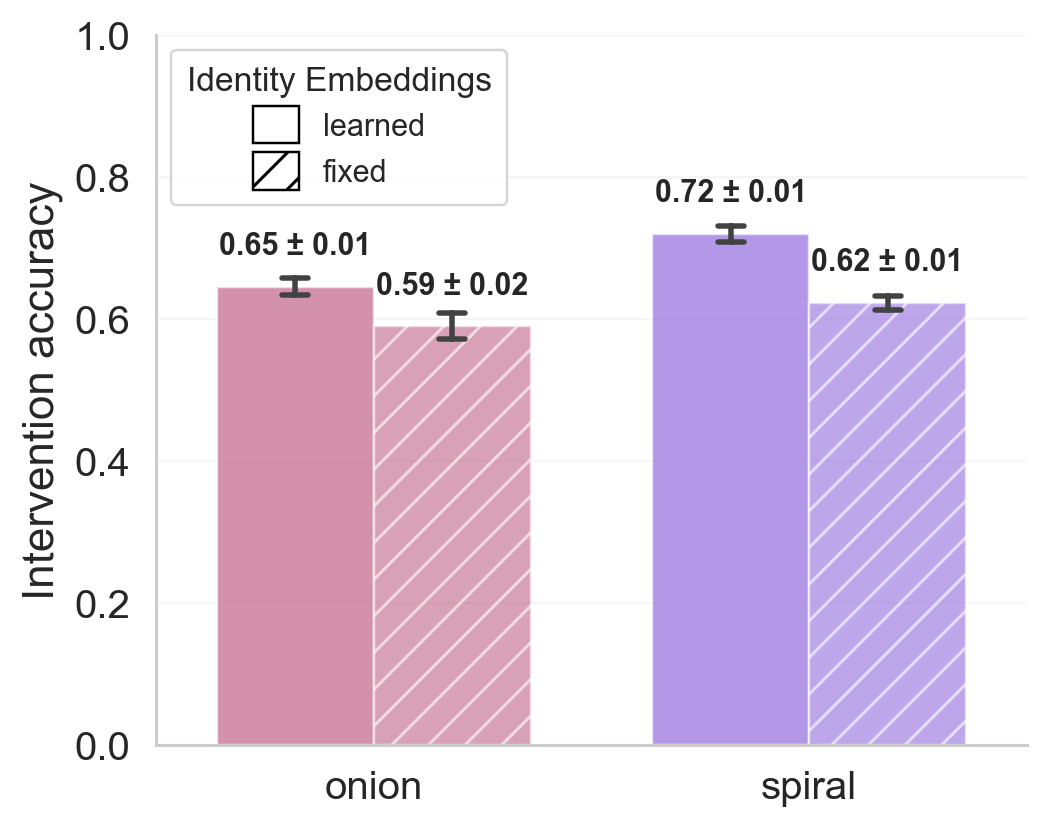

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plot_df = pd.concat([
    spiral_train_emb.assign(model="spiral", embed_type="learned"),
    spiral_freeze_emb.assign(model="spiral", embed_type="fixed"),
    onion_train_emb.assign(model="onion", embed_type="learned"),
    onion_freeze_emb.assign(model="onion", embed_type="fixed"),
    # low_rank_train_emb.assign(model="low rank (r=8)", embed_type="learned"),
    # low_rank_freeze_emb.assign(model="low rank (r=8)", embed_type="fixed"),
], ignore_index=True)

model_order = ["onion", "spiral"]
hue_order = ["learned", "fixed"]

sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)

fig, ax = plt.subplots(figsize=(5, 4), dpi=220)

sns.barplot(
    data=plot_df,
    x="model",
    y="final_test_acc",
    hue="embed_type",
    order=model_order,
    hue_order=hue_order,
    estimator="mean",
    errorbar="sd",
    capsize=0.12,
    width=0.72,
    ax=ax,
    edgecolor="black",
    linewidth=0.8,
)

# Use the actual x locations instead of patch index
xticks = ax.get_xticks()
group_centers = dict(zip(model_order, xticks))

for bar in ax.patches:
    x_center = bar.get_x() + bar.get_width() / 2
    model = min(group_centers, key=lambda m: abs(x_center - group_centers[m]))
    bar.set_facecolor(method_colors[model])
    bar.set_edgecolor("white")
    bar.set_alpha(0.7)

    # Left bar in each group = train, right bar = freeze
    if x_center > group_centers[model]:
        bar.set_hatch("//")
        bar.set_edgecolor("white")  
        bar.set_alpha(0.6)

# Labels above bars
stats = (
    plot_df.groupby(["model", "embed_type"])["final_test_acc"]
    .agg(["mean", "std"])
    .reindex(pd.MultiIndex.from_product([model_order, hue_order]))
)
# clear old labels if you rerun the cell
for txt in ax.texts[:]:
    txt.remove()

# label only the real bars
for container, embed_type in zip(ax.containers[:2], hue_order):
    for bar, model in zip(container, model_order):
        mean = stats.loc[(model, embed_type), "mean"]
        sd = stats.loc[(model, embed_type), "std"]
        if pd.isna(sd):
            sd = 0.0

        ax.annotate(
            f"{mean:.2f} ± {sd:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()+0.02),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            # bold= True,
            weight="bold",
            clip_on=False,
        )

ax.set_xlabel("")
ax.set_ylabel("Intervention accuracy")
# ax.set_title("Intervention accuracy by method", pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

legend_handles = [
    Patch(facecolor="white", edgecolor="black", label="learned"),
    Patch(facecolor="white", edgecolor="black", hatch="//", label="fixed"),
]
ax.legend( title="Identity Embeddings", handles=legend_handles, frameon=True, loc="upper left", fontsize=10, title_fontsize=11, handlelength=1.5, handleheight=1.5, borderpad=0.5, labelspacing=0.3)

ax.set_ylim(0, max(1.0, plot_df["final_test_acc"].max() + 0.12))
plt.tight_layout()
plt.show()

In [28]:
# load each method predictions
from intervention.plotting.plots import create_merged_df, load_wfe_data, load_phoneme_features

wfe_df = load_wfe_data()
phoneme_features = load_phoneme_features()


seeds = [42, 43, 44, 45]
spiral = {"train": {}, "freeze": {}}
onion = {"train": {}, "freeze": {}}
low_rank = {"train": {}, "freeze": {}}
for seed in seeds:
    # spiral["train"][seed] = pd.read_csv(f"../results/source-modified-spiral_rope-state_concat-init_delta_state_mean-train_embed/seed_{seed}/predictions.csv")
    # spiral["freeze"][seed] = pd.read_csv(f"../results/source-modified-spiral_rope-state_concat-init_delta_state_mean/seed_{seed}/predictions.csv")
    # onion["train"][seed] = pd.read_csv(f"../results/source-modified-onion-state_concat-init_delta_state_mean-train_embed/seed_{seed}/predictions.csv")
    # onion["freeze"][seed] = pd.read_csv(f"../results/source-modified-onion-state_concat-init_delta_state_mean/seed_{seed}/predictions.csv")
    # low_rank["train"][seed] = pd.read_csv(f"../results/source-modified-low_rank-8-state_concat-init_delta_state_mean-train_embed/seed_{seed}/predictions.csv")
    # low_rank["freeze"][seed] = pd.read_csv(f"../results/source-modified-low_rank-8-state_concat-init_delta_state_mean/seed_{seed}/predictions.csv")
    
    spiral["train"][seed] = create_merged_df (pd.read_csv(f"../results/source-modified-spiral_rope-state_concat-init_delta_state_mean-train_embed/seed_{seed}/predictions.csv"), wfe_df, phoneme_features)
    spiral["freeze"][seed] = create_merged_df(pd.read_csv(f"../results/source-modified-spiral_rope-state_concat-init_delta_state_mean/seed_{seed}/predictions.csv"), wfe_df, phoneme_features)
    onion["train"][seed] = create_merged_df(pd.read_csv(f"../results/source-modified-onion-state_concat-init_delta_state_mean-train_embed/seed_{seed}/predictions.csv"), wfe_df, phoneme_features)
    onion["freeze"][seed] = create_merged_df(pd.read_csv(f"../results/source-modified-onion-state_concat-init_delta_state_mean/seed_{seed}/predictions.csv"), wfe_df, phoneme_features)
    low_rank["train"][seed] = create_merged_df(pd.read_csv(f"../results/source-modified-low_rank-8-state_concat-init_delta_state_mean-train_embed/seed_{seed}/predictions.csv"), wfe_df, phoneme_features)
    low_rank["freeze"][seed] = create_merged_df(pd.read_csv(f"../results/source-modified-low_rank-8-state_concat-init_delta_state_mean/seed_{seed}/predictions.csv"), wfe_df, phoneme_features)


spiral["freeze"][42].groupby("position")["match"].mean()

position
0    0.500000
1    0.620072
2    0.665796
3    0.667360
4    0.693798
5    0.692015
6    0.624762
7    0.538760
8    0.482759
Name: match, dtype: float64

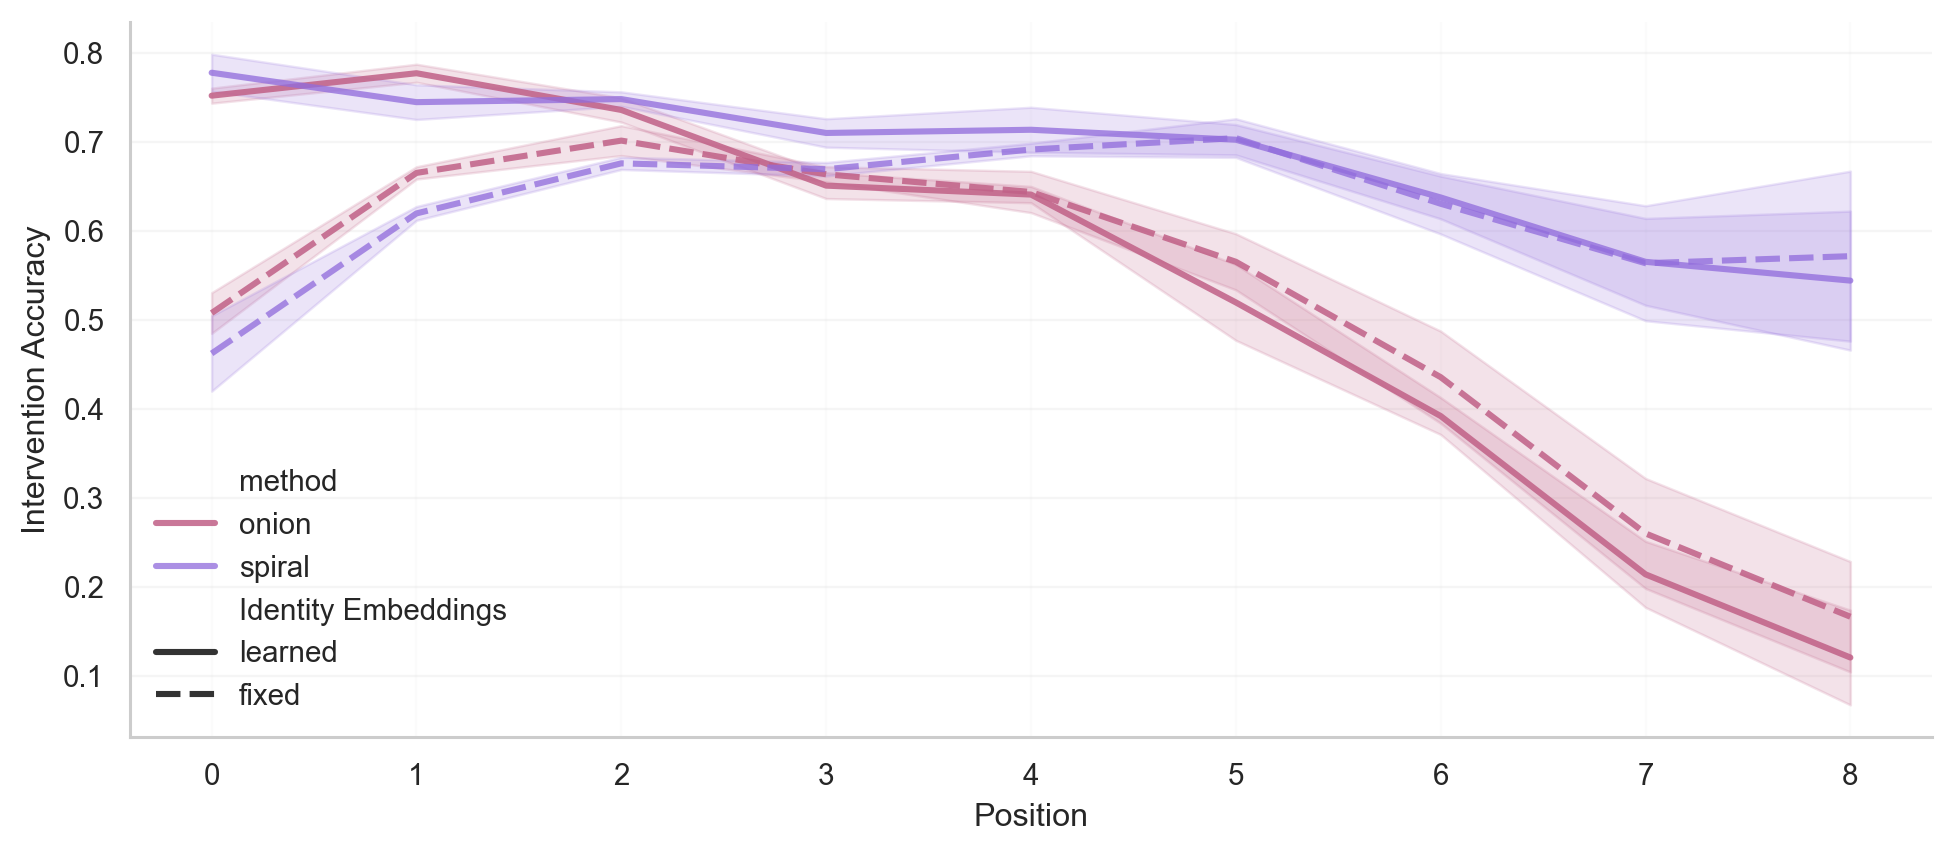

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

seeds = [42, 43, 44, 45]

runs = {
    "spiral": {
        "learned": spiral["train"],
        "fixed": spiral["freeze"],
    },
    "onion": {
        "learned": onion["train"],
        "fixed": onion["freeze"],
    },
    # "low rank (r=8)": {
    #     "learned": low_rank["train"],
    #     "fixed": low_rank["freeze"],
    # },
}

rows = []

for method, embed_dict in runs.items():
    for embed_type, seed_dict in embed_dict.items():
        for seed, df in seed_dict.items():
            pos_acc = (
                df.groupby("position")["match"]
                .mean()
                .reset_index(name="accuracy")
            )
            pos_acc["method"] = method
            pos_acc["Identity Embeddings"] = embed_type
            pos_acc["seed"] = seed
            rows.append(pos_acc)

acc_df = pd.concat(rows, ignore_index=True)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

palette = method_colors

fig, ax = plt.subplots(figsize=(9, 4), dpi=220)

sns.lineplot(
    data=acc_df,
    x="position",
    y="accuracy",
    hue="method",
    style="Identity Embeddings",
    hue_order=["onion", "spiral"],
    style_order=["learned", "fixed"],
    palette=palette,
    estimator="mean",
    errorbar="sd",   # use ci="sd" if your seaborn is older
    err_style="band",
    err_kws={"alpha": 0.18},
    linewidth=2,
    markers=False,
    ax=ax,
)

ax.set_xlabel("Position")
ax.set_ylabel("Intervention Accuracy")
# ax.set_title("Intervention Accuracy per position", pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", alpha=0.08)

ax.legend(frameon=False, title="")
plt.tight_layout()
plt.show()


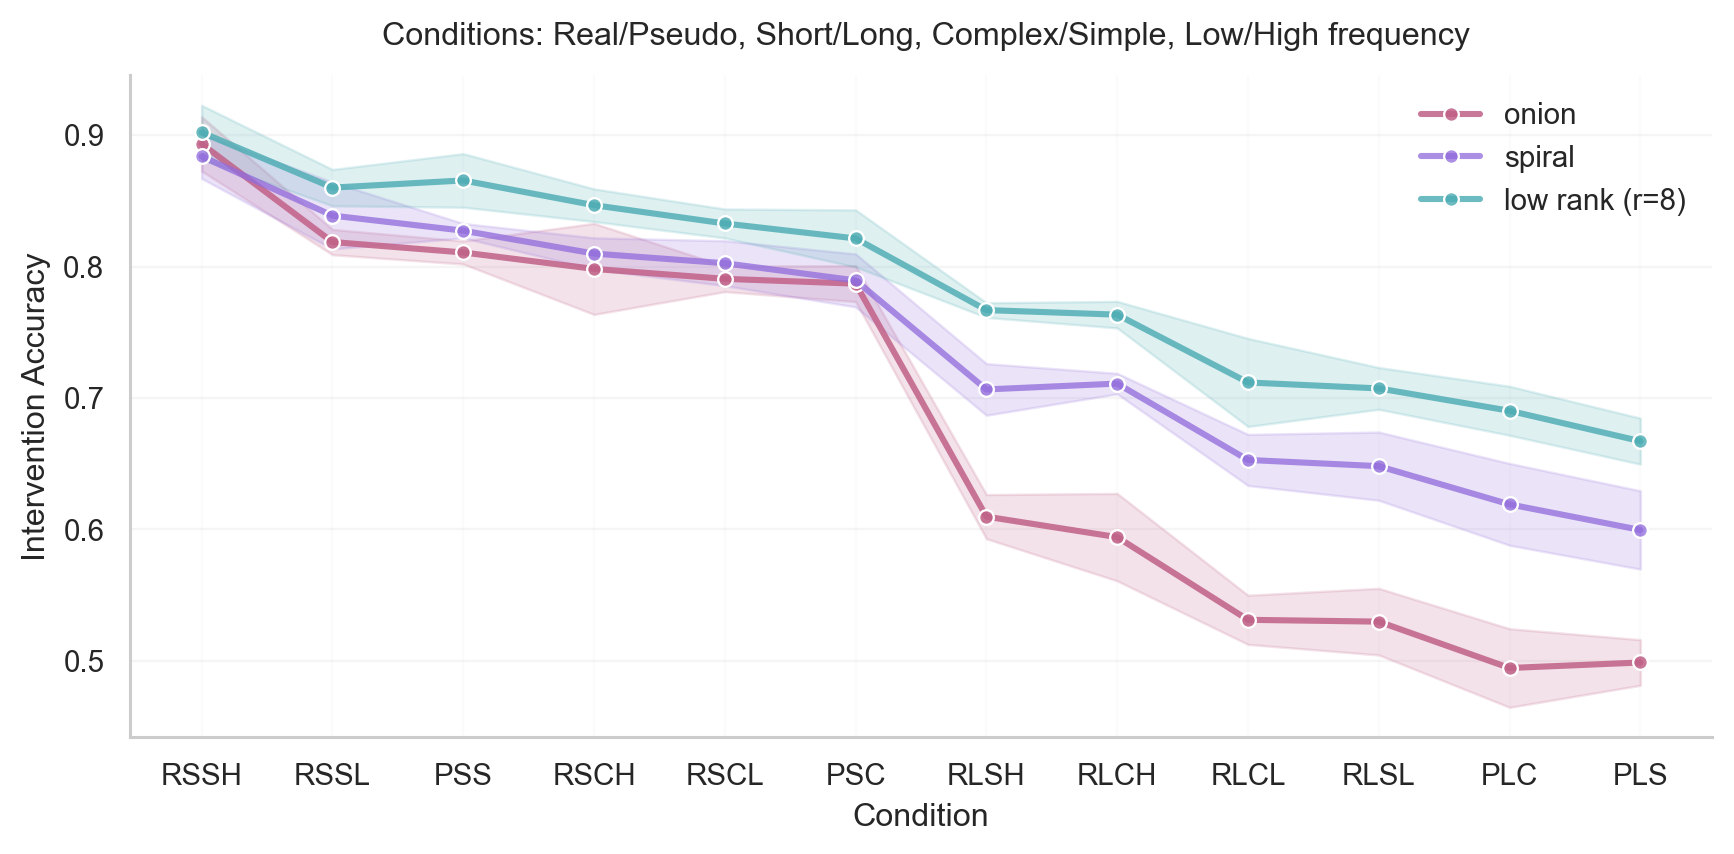

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


seeds = [42, 43, 44, 45]

runs = {
    "spiral": {
        "train": spiral["train"],
        "freeze": spiral["freeze"],
    },
    "onion": {
        "train": onion["train"],
        "freeze": onion["freeze"],
    },
    "low rank (r=8)": {
        "train": low_rank["train"],
        "freeze": low_rank["freeze"],
    },
}

rows = []

for method, embed_dict in runs.items():
    for embed_type, seed_dict in embed_dict.items():
        for seed, df in seed_dict.items():
            tmp = df.copy()

            tmp["Condition"] = tmp["Condition"].astype("string").str.strip()
            tmp["match"] = pd.to_numeric(tmp["match"], errors="coerce")

            tmp = tmp.dropna(subset=["Condition", "match"])
            tmp = tmp[tmp["Condition"].ne("nan")]
  
            cond_acc = (
                tmp.groupby("Condition", as_index=False)["match"]
                .mean()
                .rename(columns={"match": "accuracy"})
            )

            cond_acc["method"] = method
            cond_acc["embed_type"] = embed_type
            cond_acc["seed"] = seed
            rows.append(cond_acc)


acc_df = pd.concat(rows, ignore_index=True)

plot_df = acc_df[acc_df["embed_type"].eq("train")].copy()

condition_order = (
    plot_df.groupby("Condition")["accuracy"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

plot_df["Condition"] = pd.Categorical(
    plot_df["Condition"],
    categories=condition_order,
    ordered=True,
)


sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

palette = method_colors

fig, ax = plt.subplots(figsize=(8, 4), dpi=220)
sns.lineplot(
    data=plot_df,
    x="Condition",
    y="accuracy",
    hue="method",
    hue_order=["onion", "spiral", "low rank (r=8)"],
    palette=palette,
    estimator="mean",
    errorbar="sd",   # use ci="sd" if your seaborn is older
    err_style="band",
    err_kws={"alpha": 0.18},
    linewidth=2,
    marker="o",
    ax=ax,
)

ax.set_xlabel("Condition")
ax.set_ylabel("Intervention Accuracy")
ax.set_title(" Conditions: Real/Pseudo, Short/Long, Complex/Simple, Low/High frequency", pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", alpha=0.08)

ax.legend(frameon=False, title="")
plt.tight_layout()
plt.show()


In [82]:
acc_df.groupby("Condition")["accuracy"].mean().sort_values(ascending=False)

Condition
RSSH    0.831265
RSSL    0.777985
PSS     0.777881
RSCH    0.757427
RSCL    0.746158
PSC     0.741855
RLSH    0.653488
RLCH    0.647153
RLSL    0.601552
RLCL    0.601489
PLC     0.569821
PLS     0.561545
Name: accuracy, dtype: float64

In [95]:
# parameter analysis

low_rank_params = np.load("../results/source-modified-low_rank-8-state_concat-init_delta_state_mean-train_embed/seed_42/scale_params.npz")
onion_params = np.load("../results/source-modified-onion-state_concat-init_delta_state_mean-train_embed/seed_42/scale_params.npz")
spiral_params = np.load("../results/source-modified-spiral_rope-state_concat-init_delta_state_mean-train_embed/seed_42/scale_params.npz")

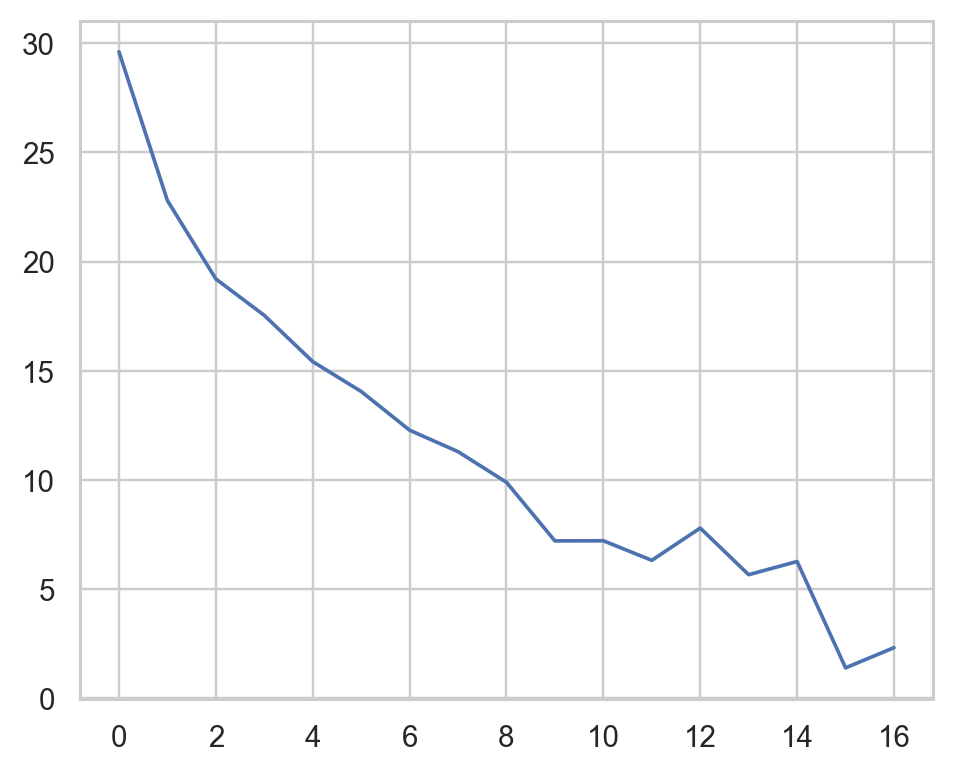

In [9]:
# plot norm of each scale per position  low_rank_params["scales"][pos]
plt.figure(figsize=(5, 4), dpi=220)
norms = np.linalg.norm(low_rank_params["scales"], axis=1)
positions = np.arange(len(norms))
plt.plot(positions, norms)

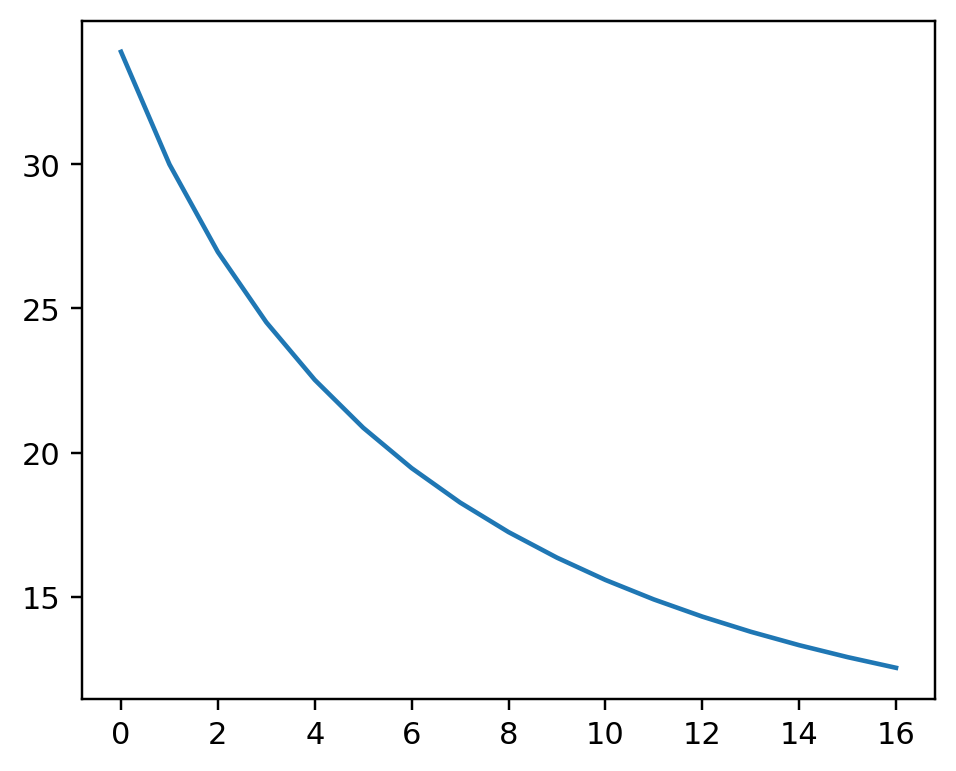

In [ ]:
# norms for spiral_out
plt.figure(figsize=(5, 4), dpi=220)
norms = np.linalg.norm(spiral_out, axis=1)
positions = np.arange(len(norms))
plt.plot(positions, norms)

In [15]:
# calculate the angle between the scales of consecutive positions
from numpy.linalg import norm
def calculate_angles(scales):
    #normalize the scales
    # scales = scales / np.linalg.norm(scales, axis=1, keepdims=True)
    angles = []
    for i in range(len(scales) - 1):
        v1 = scales[0]
        v2 = scales[i]
        cos_angle = np.dot(v1, v2) / (norm(v1) * norm(v2))
        angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))  # clip for numerical stability
        angles.append(np.degrees(angle))
    return angles



In [16]:
lr_angles = calculate_angles(low_rank_params["scales"])
onion_angles = calculate_angles(onion_params["scales"])


In [17]:
def rotate_scale(scales, rot_freq):          # scales: (P, D), rot_freq: (D/2,)
    P, D = scales.shape
    pos = np.arange(P)
    ang = np.outer(pos, rot_freq)             # (P, D/2)
    e, o = scales[:, 0::2], scales[:, 1::2]
    c, s = np.cos(ang), np.sin(ang)
    out = np.empty_like(scales)
    out[:, 0::2] = e*c - o*s
    out[:, 1::2] = e*s + o*c
    return out

spiral_out = rotate_scale(spiral_params["scales"], spiral_params["rot_freq"])


Text(0, 0.5, 'PC2, var=0.24')

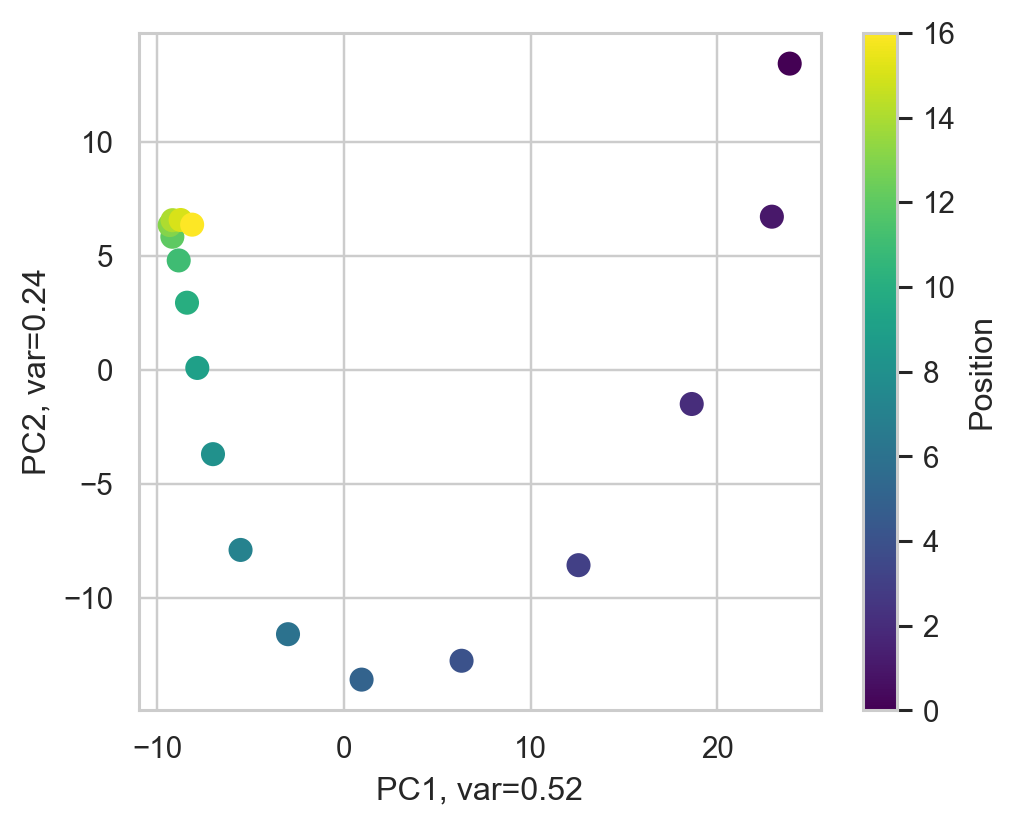

In [26]:
# plot pca of scales per position (graidient color)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
scales_2d = pca.fit_transform(spiral_out)
plt.figure(figsize=(5, 4), dpi=220)
plt.scatter(scales_2d[:, 0], scales_2d[:, 1],
            c=np.arange(len(scales_2d)), cmap='viridis', s=50)
plt.colorbar(label='Position')
plt.xlabel('PC1, var={:.2f}'.format(pca.explained_variance_ratio_[0]))
plt.ylabel('PC2, var={:.2f}'.format(pca.explained_variance_ratio_[1]))

In [18]:
spiral_angles = calculate_angles(spiral_out)

Text(0.5, 1.0, 'Angle to the First Position')

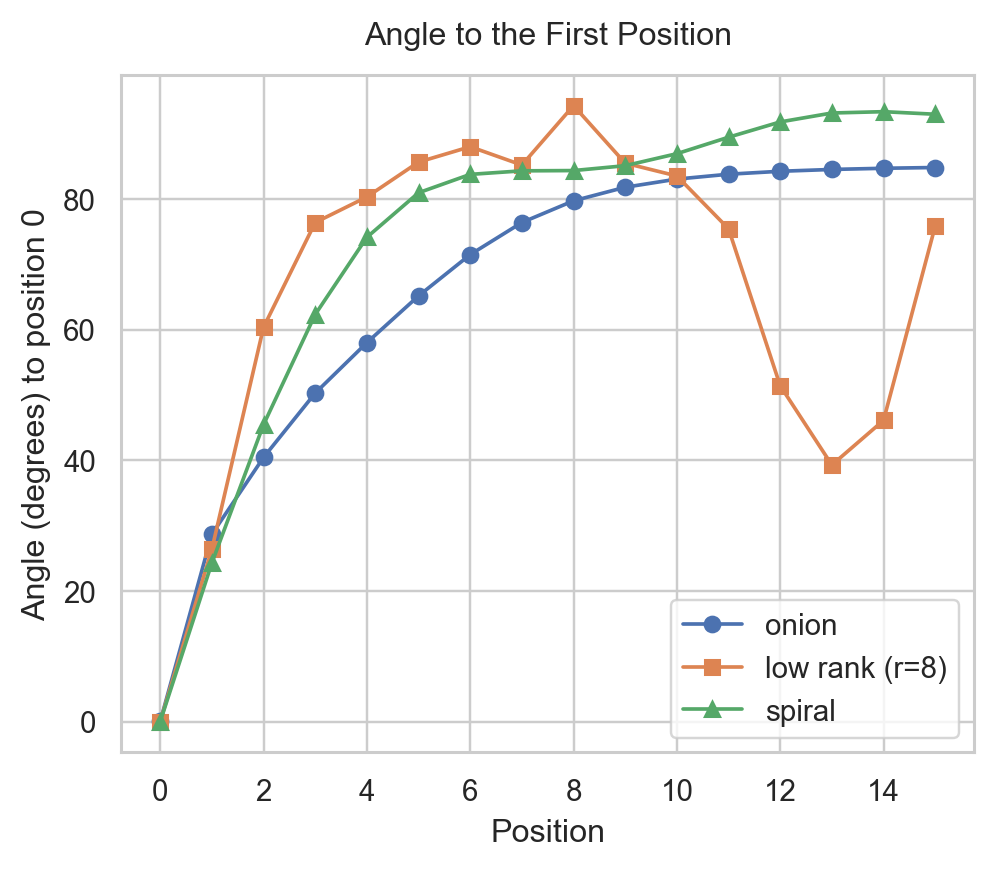

In [19]:
# plot the angles
plt.figure(figsize=(5, 4), dpi=220)
plt.plot(range(len(onion_angles)), onion_angles, marker='o')
plt.plot(range(len(lr_angles)), lr_angles, marker='s')
plt.plot(range(len(spiral_angles)), spiral_angles, marker='^')
plt.xlabel('Position')
plt.ylabel('Angle (degrees) to position 0')
plt.legend(["onion", "low rank (r=8)", "spiral"])
plt.title("Angle to the First Position", pad=10)

paper_plots.ipynb  r-r.ipynb          trajectory.ipynb
plots.py           report_plots.ipynb


In [12]:
import sys, pathlib
# repo root = one level up from intervention/notebooks/
root = pathlib.Path.cwd().parents[1] 
sys.path.insert(0, str(root))

from intervention.state_analysis.states_extract import StatesDataset


states_path = str(STATES_DIR / "train_states")
states_ds = StatesDataset.load(states_path)

Positions: 100%|██████████| 13/13 [00:01<00:00, 12.95it/s]


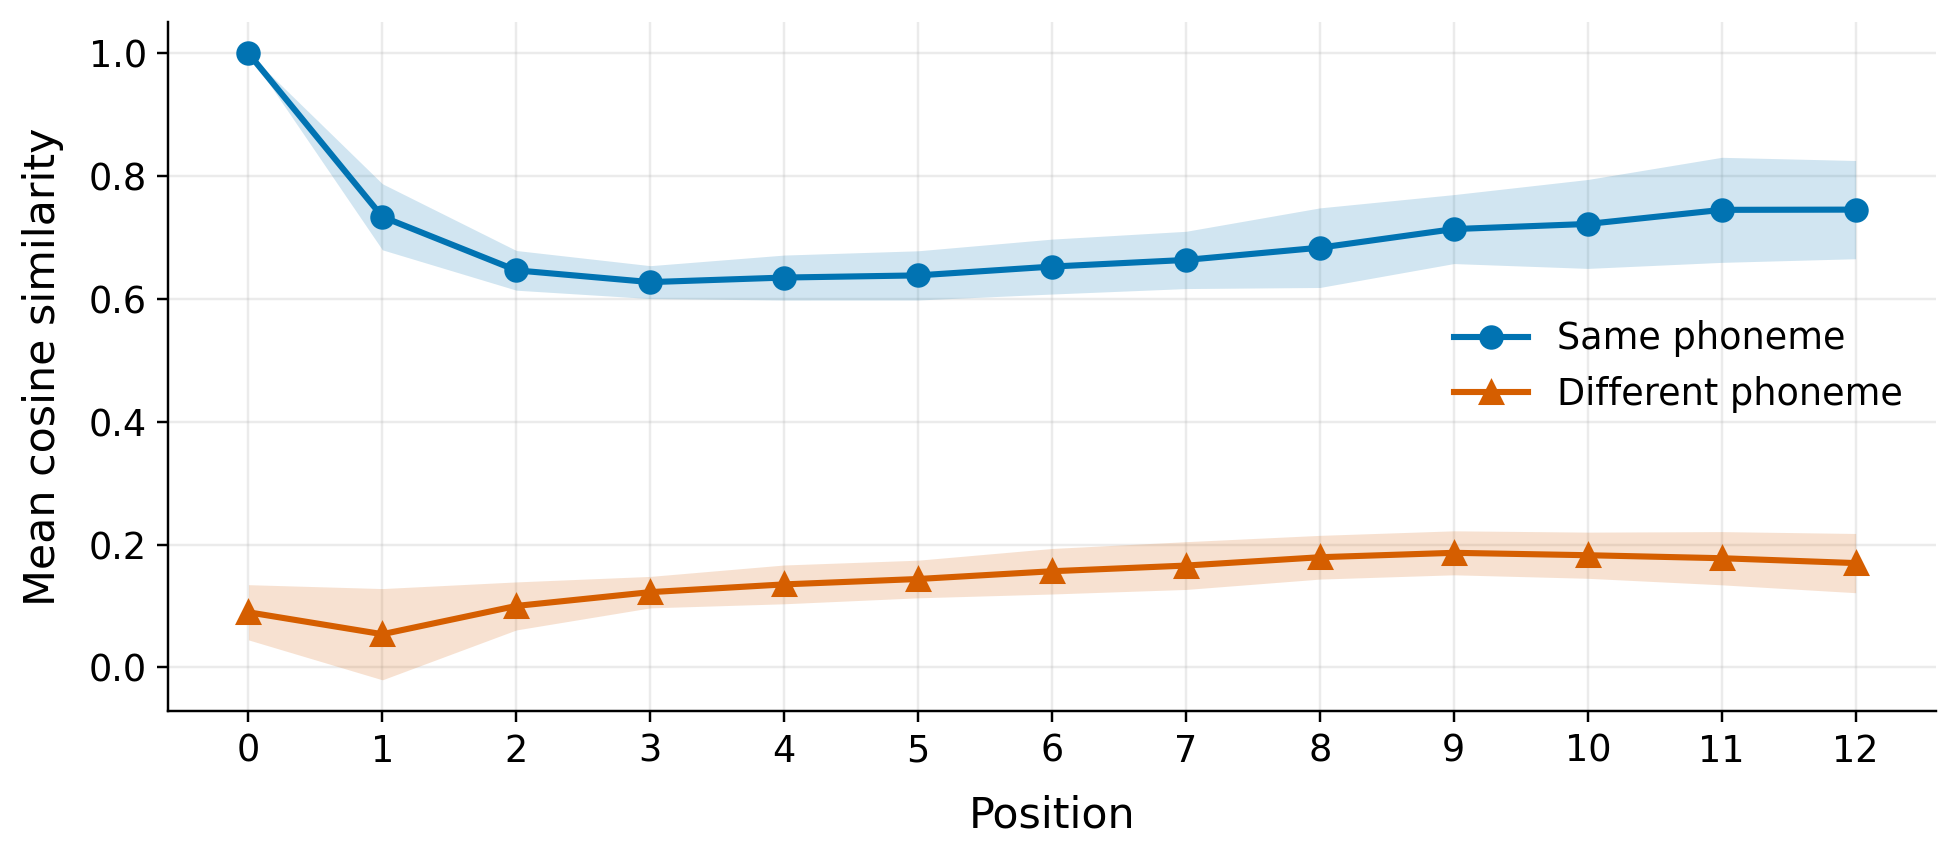

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

def plot_delta_z_similarity(dataset, state_col='delta_state', max_samples=200, band='std'):
    """
    Computes and plots cosine similarities for delta states, with margins.
    Each line is a mean over phonemes; the shaded band is the spread across
    phonemes (band='sem' -> +/-1 SEM, band='std' -> +/-1 std).
    Limits samples to avoid Out-Of-Memory (OOM) errors.
    """
    metadata = dataset.metadata.copy()
    states = getattr(dataset, state_col)

    positions = range(0, 13)
    phonemes = metadata['phoneme'].unique()

    # Subsample indices for each (phoneme, position) to save memory
    np.random.seed(42)
    idx_dict = {}
    for (ph, p), group in metadata.groupby(['phoneme', 'position']):
        idx = group.index.values
        if len(idx) > max_samples:
            idx = np.random.choice(idx, max_samples, replace=False)
        idx_dict[(ph, p)] = idx

    # per-position lists of per-phoneme values -> mean gives the line, spread gives the band
    spsp, spdp, dpsp = [], [], []  # Same/Same, Same/Diff, Diff/Same

    def summarize(vals):
        vals = np.asarray(vals, dtype=float)
        if vals.size == 0:
            return np.nan, np.nan
        mean = np.nanmean(vals)
        n = np.sum(~np.isnan(vals))
        spread = np.nanstd(vals)
        if band == 'sem' and n > 1:
            spread = spread / np.sqrt(n)
        return mean, spread

    for p in tqdm(positions, desc="Positions"):
        # 1. Same phoneme, same position -> one value per phoneme
        v_spsp = []
        for ph in phonemes:
            idx = idx_dict.get((ph, p), [])
            if len(idx) > 1:
                sim = cosine_similarity(states[idx])
                triu = np.triu_indices_from(sim, k=1)
                if len(triu[0]) > 0:
                    v_spsp.append(sim[triu].mean())
        spsp.append(summarize(v_spsp))

        # # 2. Same phoneme, different position -> one value per phoneme
        # v_spdp = []
        # for ph in phonemes:
        #     idx_p = idx_dict.get((ph, p), [])
        #     idx_not_p = []
        #     for other_p in positions:
        #         if other_p != p:
        #             idx_not_p.extend(idx_dict.get((ph, other_p), []))
        #     if len(idx_p) > 0 and len(idx_not_p) > 0:
        #         sim = cosine_similarity(states[idx_p], states[idx_not_p])
        #         v_spdp.append(sim.mean())
        # spdp.append(summarize(v_spdp))

        # 3. Different phoneme, same position -> one value per phoneme
        all_idx_p, all_ph_p = [], []
        for ph in phonemes:
            idx = idx_dict.get((ph, p), [])
            all_idx_p.extend(idx)
            all_ph_p.extend([ph] * len(idx))
        all_idx_p = np.array(all_idx_p)
        all_ph_p = np.array(all_ph_p)

        v_dpsp = []
        if len(all_idx_p) > 1:
            if len(all_idx_p) > 2000:
                sub = np.random.choice(len(all_idx_p), 2000, replace=False)
                all_idx_p, all_ph_p = all_idx_p[sub], all_ph_p[sub]
            sim = cosine_similarity(states[all_idx_p])
            for ph in phonemes:
                row = all_ph_p == ph
                col = all_ph_p != ph
                if row.any() and col.any():
                    v_dpsp.append(sim[np.ix_(row, col)].mean())
        dpsp.append(summarize(v_dpsp))

    x = list(positions)
    spsp_m, spsp_e = np.array(spsp).T
    # spdp_m, spdp_e = np.array(spdp).T
    dpsp_m, dpsp_e = np.array(dpsp).T

    # Plotting
    fig, ax = plt.subplots(figsize=(9, 4), dpi=220)
    cb = sns.color_palette("colorblind")
    same_ph, diff_ph = cb[0], cb[3]  # blue = same phoneme, red = different phoneme

    def line(m, e, color, ls, marker, label):
        ax.plot(x, m, color=color, linestyle=ls, marker=marker, markersize=7,
                linewidth=2, label=label)
        ax.fill_between(x, m - e, m + e, color=color, alpha=0.18, linewidth=0)

    line(spsp_m, spsp_e, same_ph, '-',  'o', 'Same phoneme')
    # line(spdp_m, spdp_e, same_ph, '--', 's', 'Same phoneme · different position')
    line(dpsp_m, dpsp_e, diff_ph, '-',  '^', 'Different phoneme')

    ax.set_xlabel('Position', fontsize=14, labelpad=8)
    ax.set_ylabel('Mean cosine similarity', fontsize=14, labelpad=8)
    ax.set_xticks(x)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(axis='both', alpha=0.25, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(fontsize=12, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig("delta_z_similarity_by_position.pdf", bbox_inches="tight")
    plt.show()

# Run the function on your dataset
plot_delta_z_similarity(states_ds, state_col='delta_state', max_samples=1000)


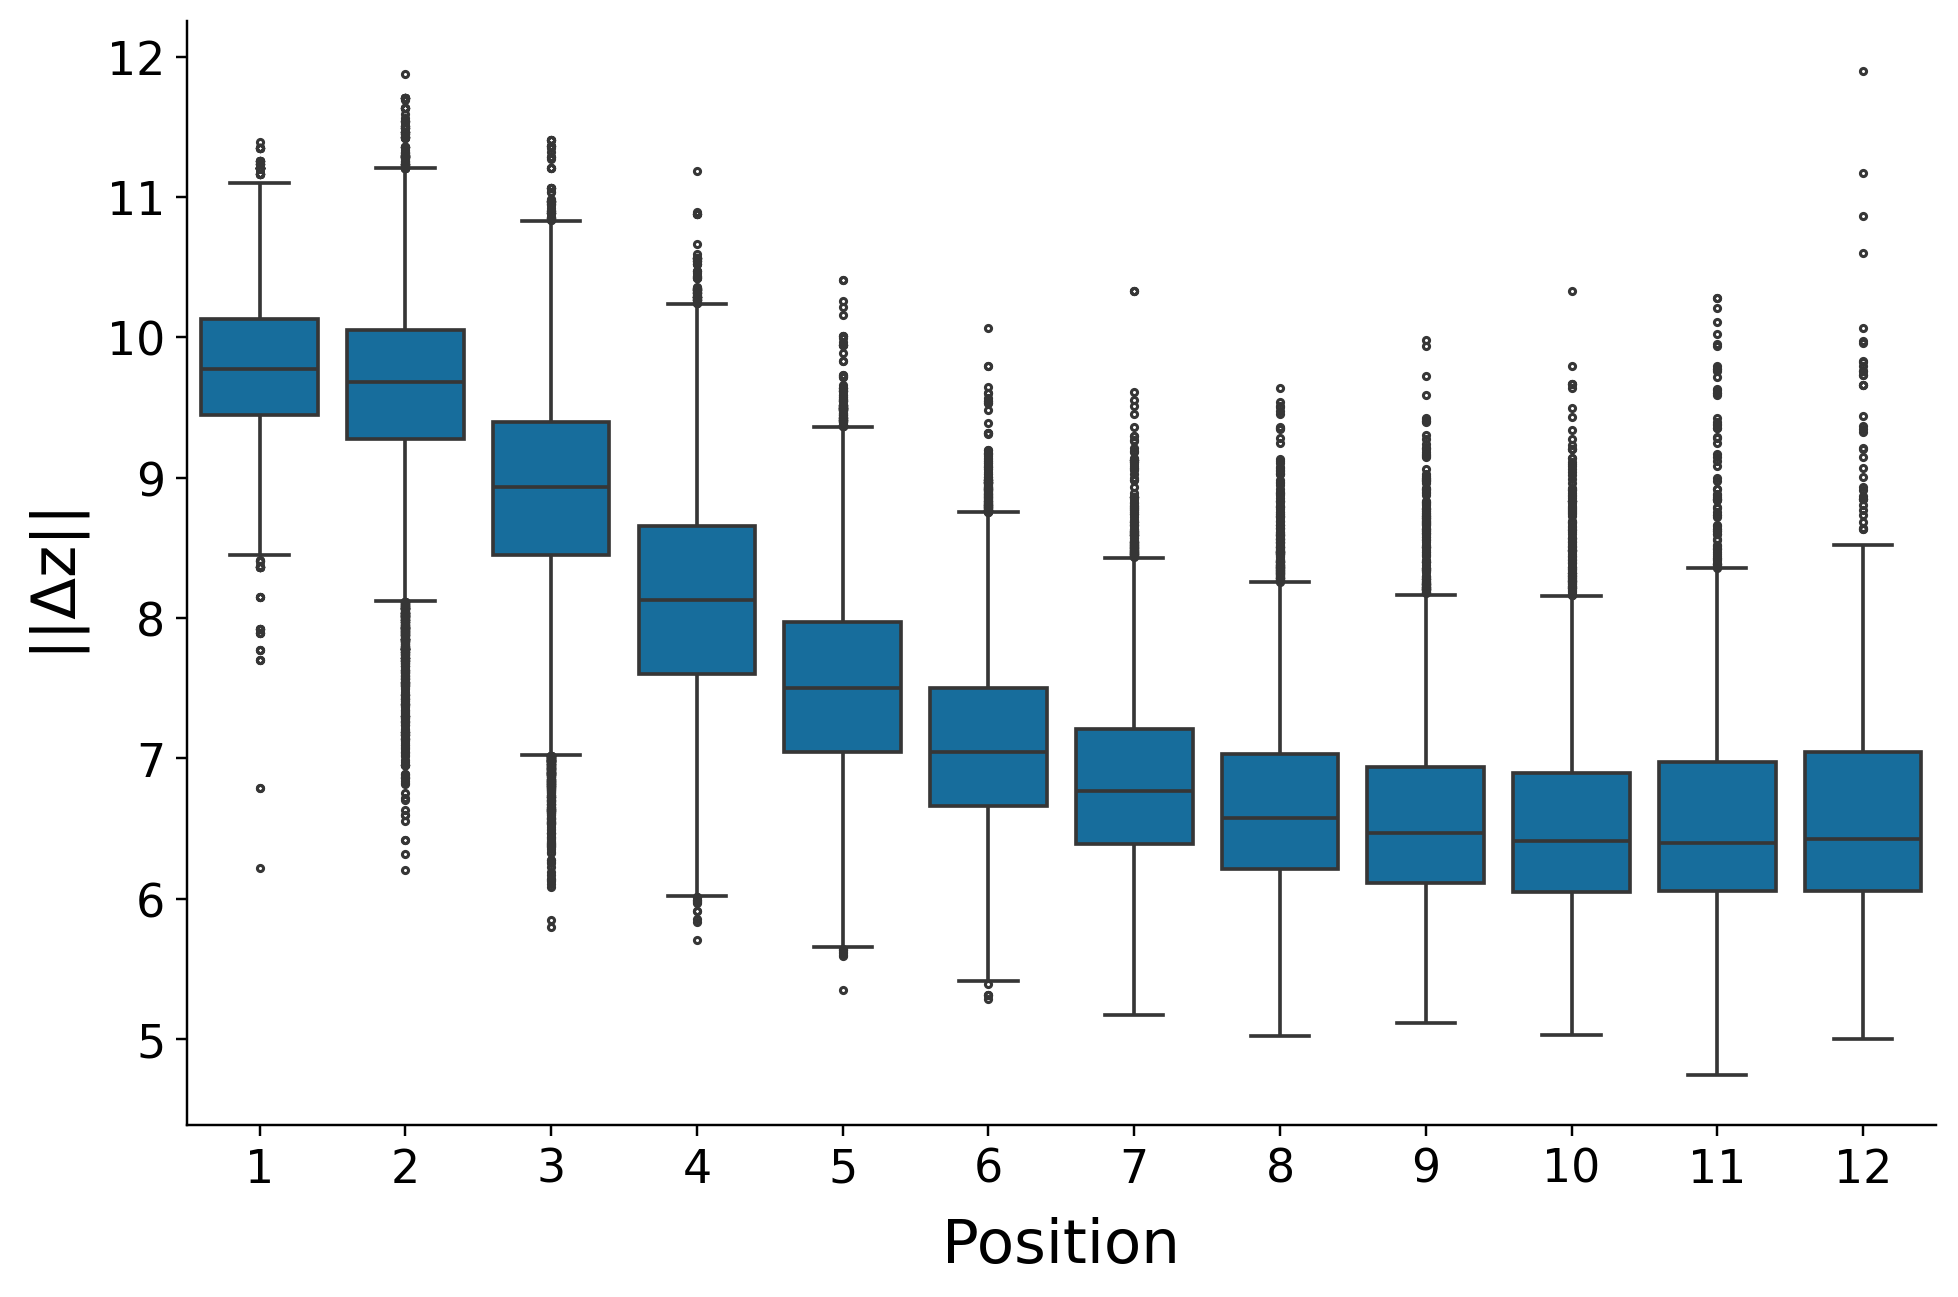

In [19]:
def norms(embeddings: np.ndarray) -> np.ndarray:
    """L2 norm of each row. Input: (N, D) → Output: (N,)"""
    return np.linalg.norm(embeddings, axis=-1) #axis=-1 means compute norm across the last dimension (D)

def norms_boxplot(dataset, embed_type="state", title="",max_pos=13, drop_first=False):
    all_norms = norms(dataset.get_embeddings(embed_type))
    df = dataset.metadata.copy()
    df["norm"] = all_norms
    if drop_first:
        df = df[df["position"] != 0]
    df = df[df["position"] < max_pos]

    fig, ax = plt.subplots(figsize=(9, 6), dpi=220)
    sns.boxplot(x="position", y="norm", data=df, ax=ax,
                color=sns.color_palette("colorblind")[0],
                fliersize=2, linewidth=1.2)

    ax.set_xlabel("Position", fontsize=20, labelpad=8)
    ax.set_ylabel(f"||Δz||", fontsize=20, labelpad=8)
    ax.tick_params(axis='both', labelsize=15)
    ax.spines[['top', 'right']].set_visible(False)
    if title:
        ax.set_title(title, fontsize=18)

    plt.tight_layout()
    # plt.savefig(f"{embed_type}_norms_by_position.pdf", bbox_inches="tight")


norms_boxplot(states_ds,embed_type="delta_state", drop_first=True)


In [21]:
states_ds.metadata

,seq_id,word,position,phoneme,phoneme_type
0,0,the,0,DH,C
1,0,the,1,AH,V
2,0,the,2,<EOS>,EOS
3,1,to,0,T,C
4,1,to,1,UW,V
...,...,...,...,...,...
217224,29999,dislocation,6,EY,V
217225,29999,dislocation,7,SH,C
217226,29999,dislocation,8,AH,V
217227,29999,dislocation,9,N,C


In [22]:
import numpy as np
def calculate_ID(X):
    Xc = X - X.mean(0)
    # singular values -> variance per component
    s = np.linalg.svd(Xc, compute_uv=False)
    var = s**2 / (len(X) - 1)

    # (a) how many PCs to reach 90% variance
    cum = np.cumsum(var) / var.sum()
    d_90 = np.searchsorted(cum, 0.90) + 1

    # (b) participation ratio (soft "effective dimension")
    pr = var.sum()**2 / (var**2).sum()
    return d_90, pr


In [23]:
def ID_per_position(positions, embs):
    d_90_list = []
    pr_values = []
    for pos in positions:
        X_pos = embs[states_ds.metadata.position == pos]
        d_90, pr = calculate_ID(X_pos)
        d_90_list.append(d_90)
        pr_values.append(pr)
    return d_90_list, pr_values

In [24]:
z_d90, z_pr = ID_per_position(range(0,16), states_ds.state)
delta_z_d90, delta_z_pr = ID_per_position(range(0,16), states_ds.delta_state)
c_d90, c_pr = ID_per_position(range(0,16), states_ds.c)
delta_c_d90, delta_c_pr = ID_per_position(range(0,16), states_ds.delta_c)
h_d90, h_pr = ID_per_position(range(0,16), states_ds.h)
delta_h_d90, delta_h_pr = ID_per_position(range(0,16), states_ds.delta_h)

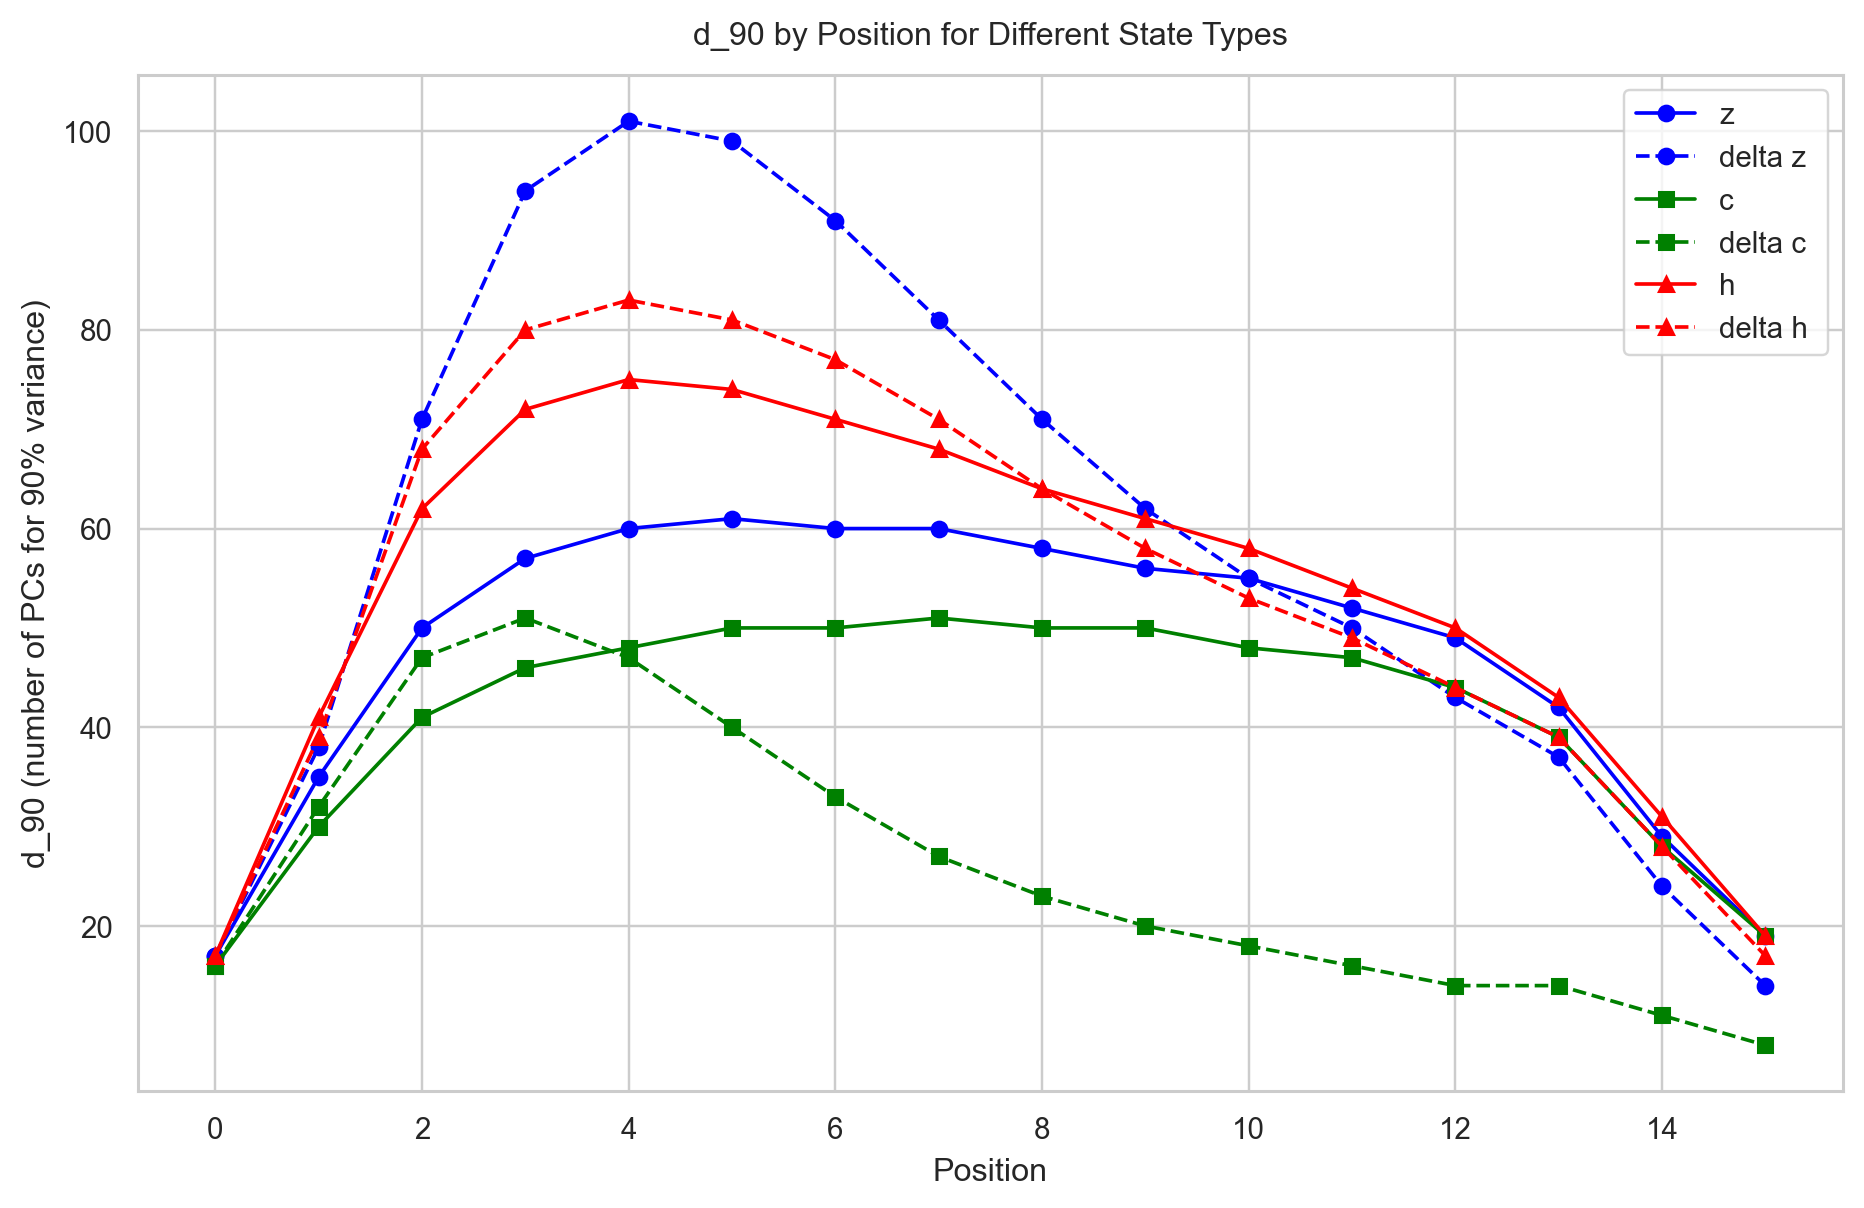

In [29]:
#plot the d_90 and pr values for each state type by position
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6), dpi=220)
positions = np.arange(16)
plt.plot(positions, z_d90, marker='o', label='z', color='blue')
plt.plot(positions, delta_z_d90, marker='o', linestyle='--', label='delta z ', color='blue')
plt.plot(positions, c_d90, marker='s', label='c', color='green')
plt.plot(positions, delta_c_d90, marker='s', linestyle='--', label='delta c ', color='green')
plt.plot(positions, h_d90, marker='^', label='h', color='red')
plt.plot(positions, delta_h_d90, marker='^', linestyle='--', label='delta h ', color='red')
plt.xlabel('Position')
plt.ylabel('d_90 (number of PCs for 90% variance)')
plt.title('d_90 by Position for Different State Types', pad=10)
plt.legend()


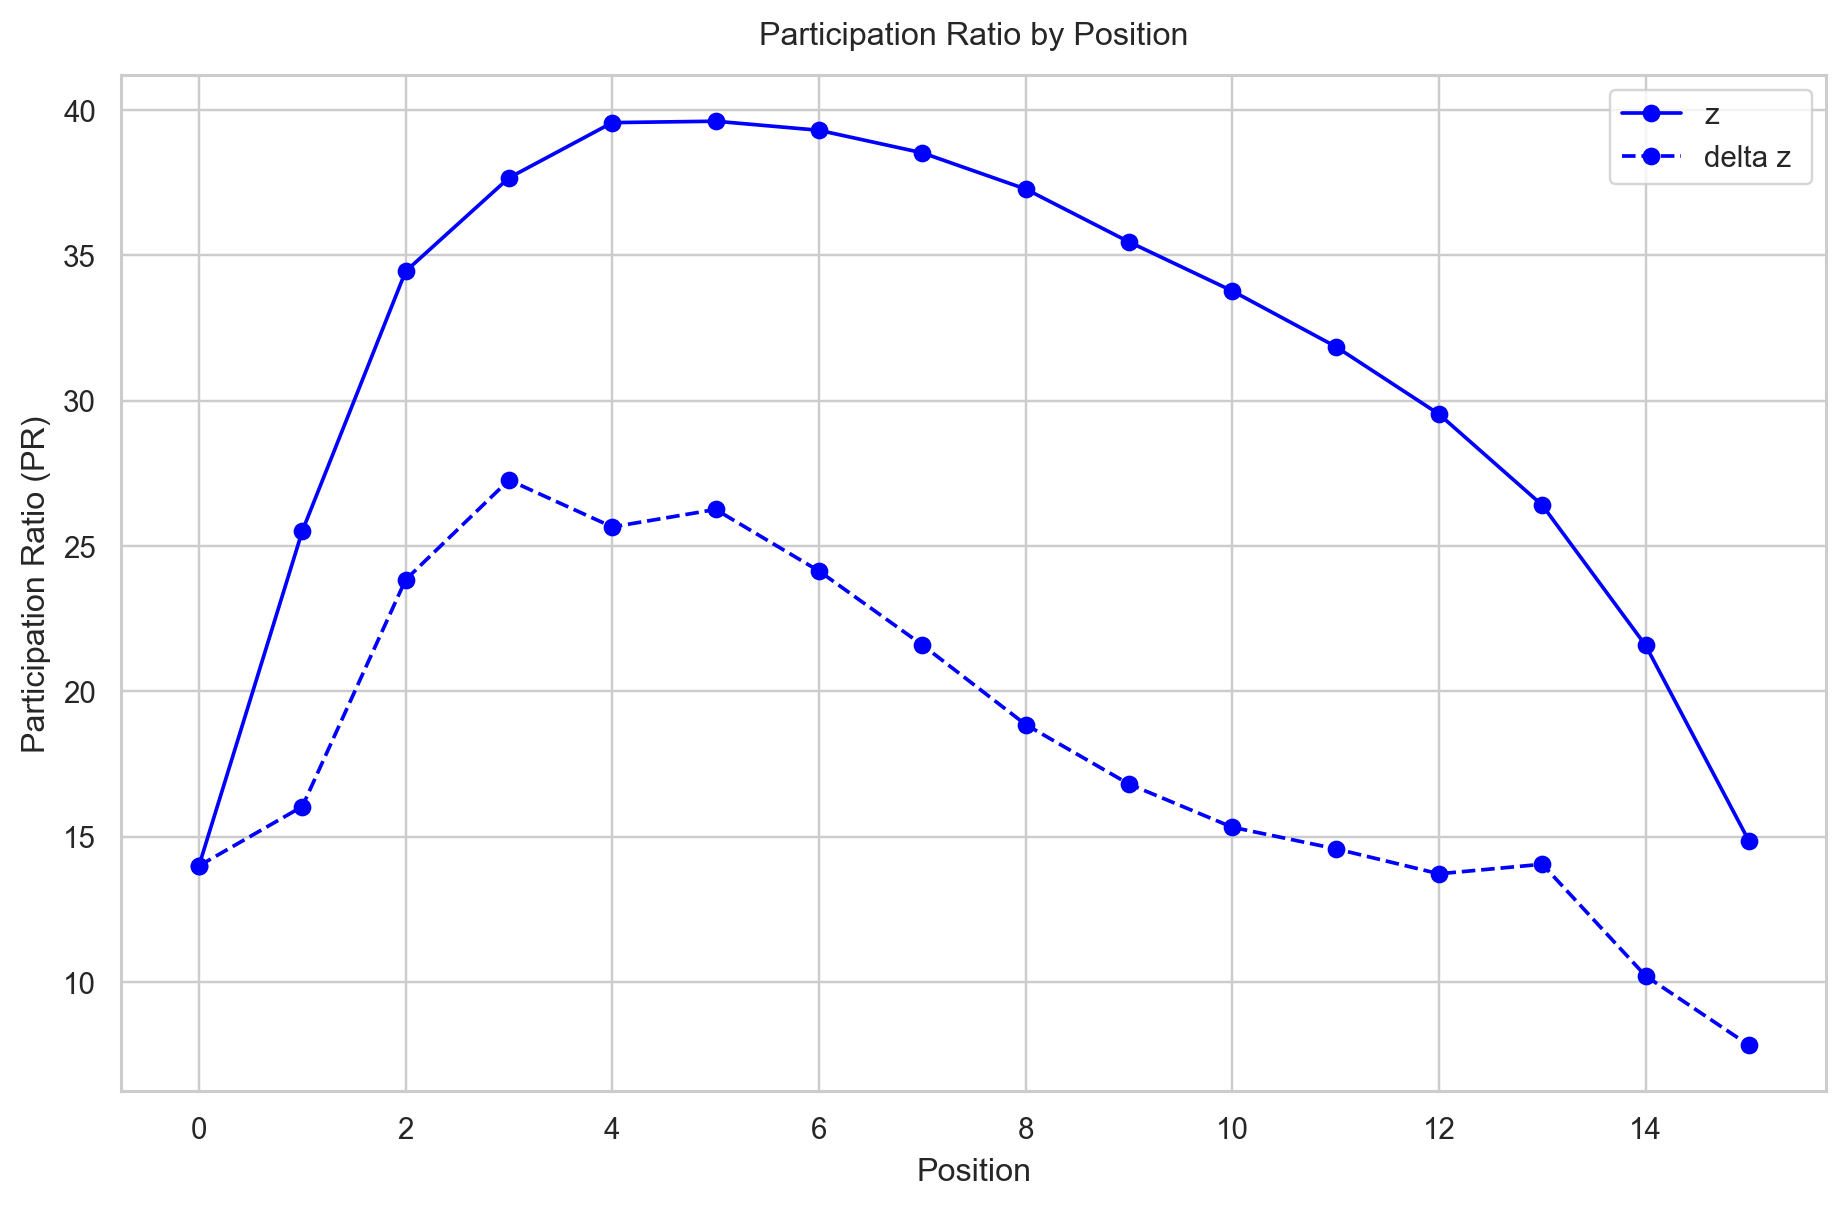

In [31]:
#plot for pr
plt.figure(figsize=(10, 6), dpi=220)
plt.plot(positions, z_pr, marker='o', label='z', color='blue')
plt.plot(positions, delta_z_pr, marker='o', linestyle='--', label='delta z ', color='blue')
# plt.plot(positions, c_pr, marker='s', label='c', color='green')
# plt.plot(positions, delta_c_pr, marker='s', linestyle='--', label='delta c ', color='green')
# plt.plot(positions, h_pr, marker='^', label='h', color='red')
# plt.plot(positions, delta_h_pr, marker='^', linestyle='--', label='delta h ', color='red')
plt.xlabel('Position')
plt.ylabel('Participation Ratio (PR)')
plt.title('Participation Ratio by Position', pad=10)
plt.legend()

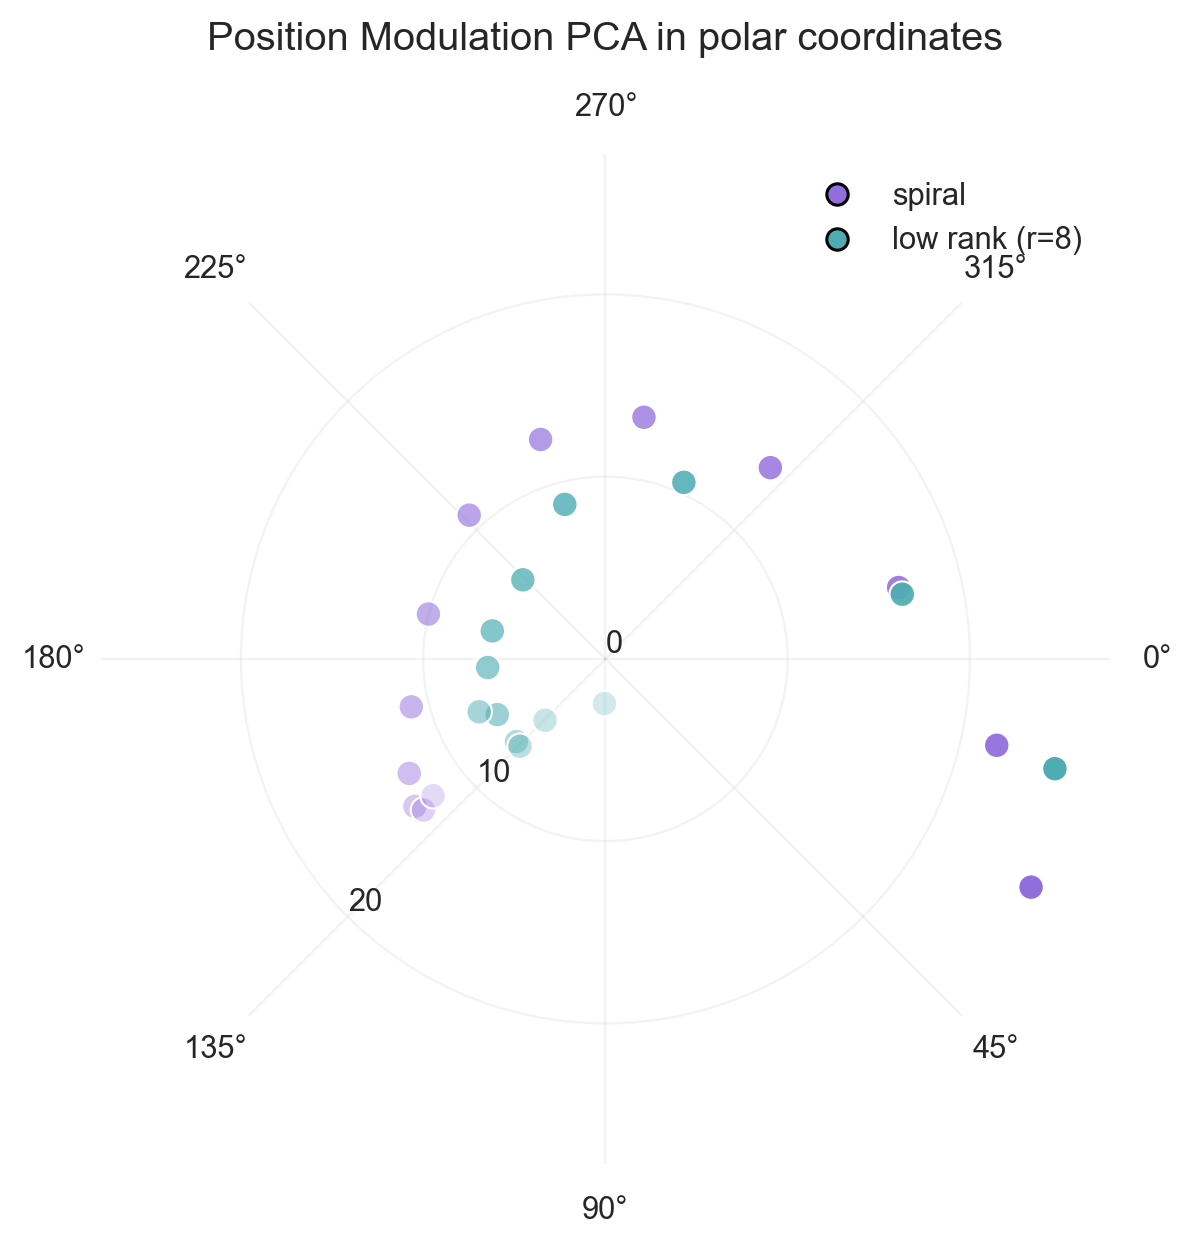

In [159]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

sns.set_theme(style="white", context="paper", font_scale=1.15)

methods = {
    "spiral": spiral_out[:13],
    # "onion": onion_params["scales"][:13],
    "low rank (r=8)": low_rank_params["scales"][:13],
}

method_colors = {
    "spiral": "#926DDC",
    "onion": "#C16288",
    "low rank (r=8)": "#4EADB4",
}

# shared PCA so all methods are in the same space
# all_scales = np.concatenate(list(methods.values()), axis=0)
# pca = PCA(n_components=2)
# pca.fit(all_scales)

fig, ax = plt.subplots(figsize=(6.4, 5.8), subplot_kw={"projection": "polar"}, dpi=220)

for method, scales in methods.items():
    pca = PCA(n_components=2)
    scales_2d = pca.fit_transform(scales)
    angles = np.arctan2(scales_2d[:, 1], scales_2d[:, 0])
    radii = np.linalg.norm(scales_2d, axis=1)

    alphas = np.linspace(1.0, 0.25, len(scales_2d))
    rgba_colors = [
        (*plt.matplotlib.colors.to_rgb(method_colors[method]), alpha)
        for alpha in alphas
    ]

    ax.scatter(
        angles,
        radii,
        s=70,
        c=rgba_colors,
        edgecolors="white",
        linewidths=0.7,
    )

ax.set_theta_zero_location("E")
ax.set_theta_direction(-1)
ax.set_rticks([0, 10, 20])
ax.set_rlabel_position(135)
ax.grid(alpha=0.22, linewidth=0.8)
ax.spines["polar"].set_visible(False)

ax.set_title("Position Modulation PCA in polar coordinates", pad=14, fontsize=13)

legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=method_colors["spiral"], label="spiral", markersize=7),
    # Line2D([0], [0], marker="o", color="none", markerfacecolor=method_colors["onion"], label="onion", markersize=7),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=method_colors["low rank (r=8)"], label="low rank (r=8)", markersize=7),
]
ax.legend(handles=legend_handles, frameon=False, title="", loc="upper right")

plt.tight_layout()
plt.show()

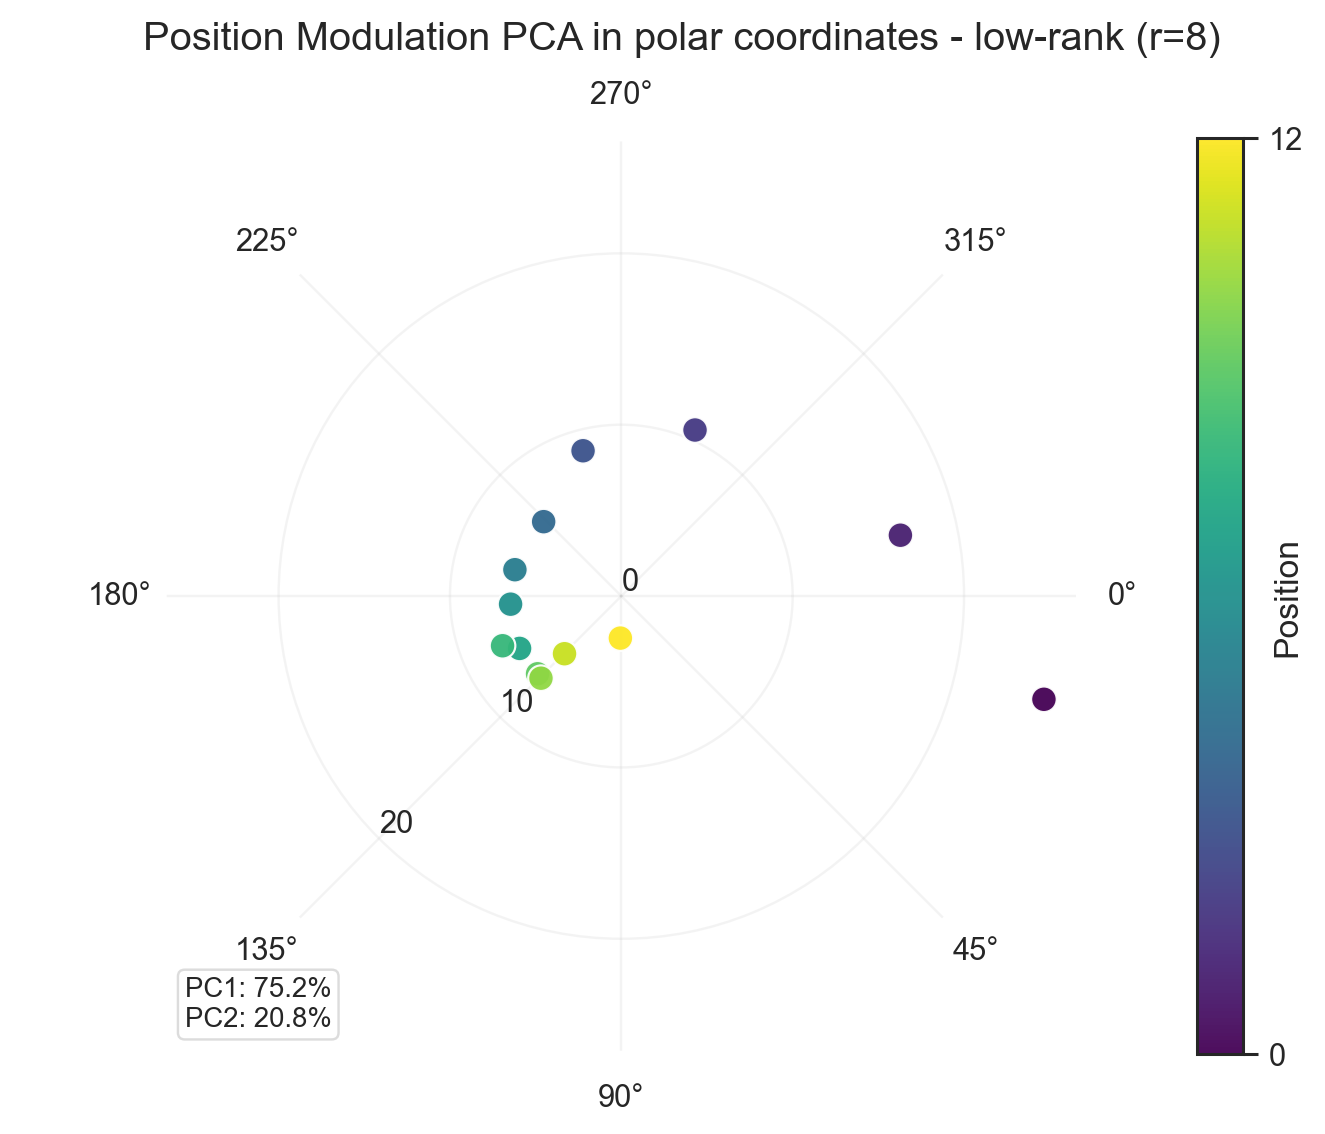

In [134]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="white", context="paper", font_scale=1.15)

pca = PCA(n_components=2)
scales_2d = pca.fit_transform(low_rank_params["scales"][:13])

angles = np.arctan2(scales_2d[:, 1], scales_2d[:, 0])
r = np.linalg.norm(scales_2d, axis=1)
pos = np.arange(len(scales_2d))

fig, ax = plt.subplots(figsize=(6.2, 5.6), subplot_kw={"projection": "polar"}, dpi=220)

scatter = ax.scatter(
    angles,
    r,
    c=pos,
    cmap="viridis",
    s=70,
    alpha=0.95,
    edgecolors="white",
    linewidths=0.7,
)

ax.set_title(
    "           Position Modulation PCA in polar coordinates - low-rank (r=8)",
    pad=10,
    fontsize=13,
)

ax.set_theta_zero_location("E")
ax.set_theta_direction(-1)

ax.set_rticks([0, 10, 20])
ax.set_rlabel_position(135)
ax.grid(alpha=0.22, linewidth=0.8)

ax.spines["polar"].set_visible(False)

cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.82)
cbar.set_label("Position", rotation=90, labelpad=-10)
cbar.set_ticks([0, len(scales_2d) - 1])

# Put the PCA variance in a compact note instead of x/y labels
var1, var2 = pca.explained_variance_ratio_[:2] * 100
ax.text(
    0.02,
    0.02,
    f"PC1: {var1:.1f}%\nPC2: {var2:.1f}%",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.85", alpha=0.9),
)

plt.tight_layout()
plt.show()

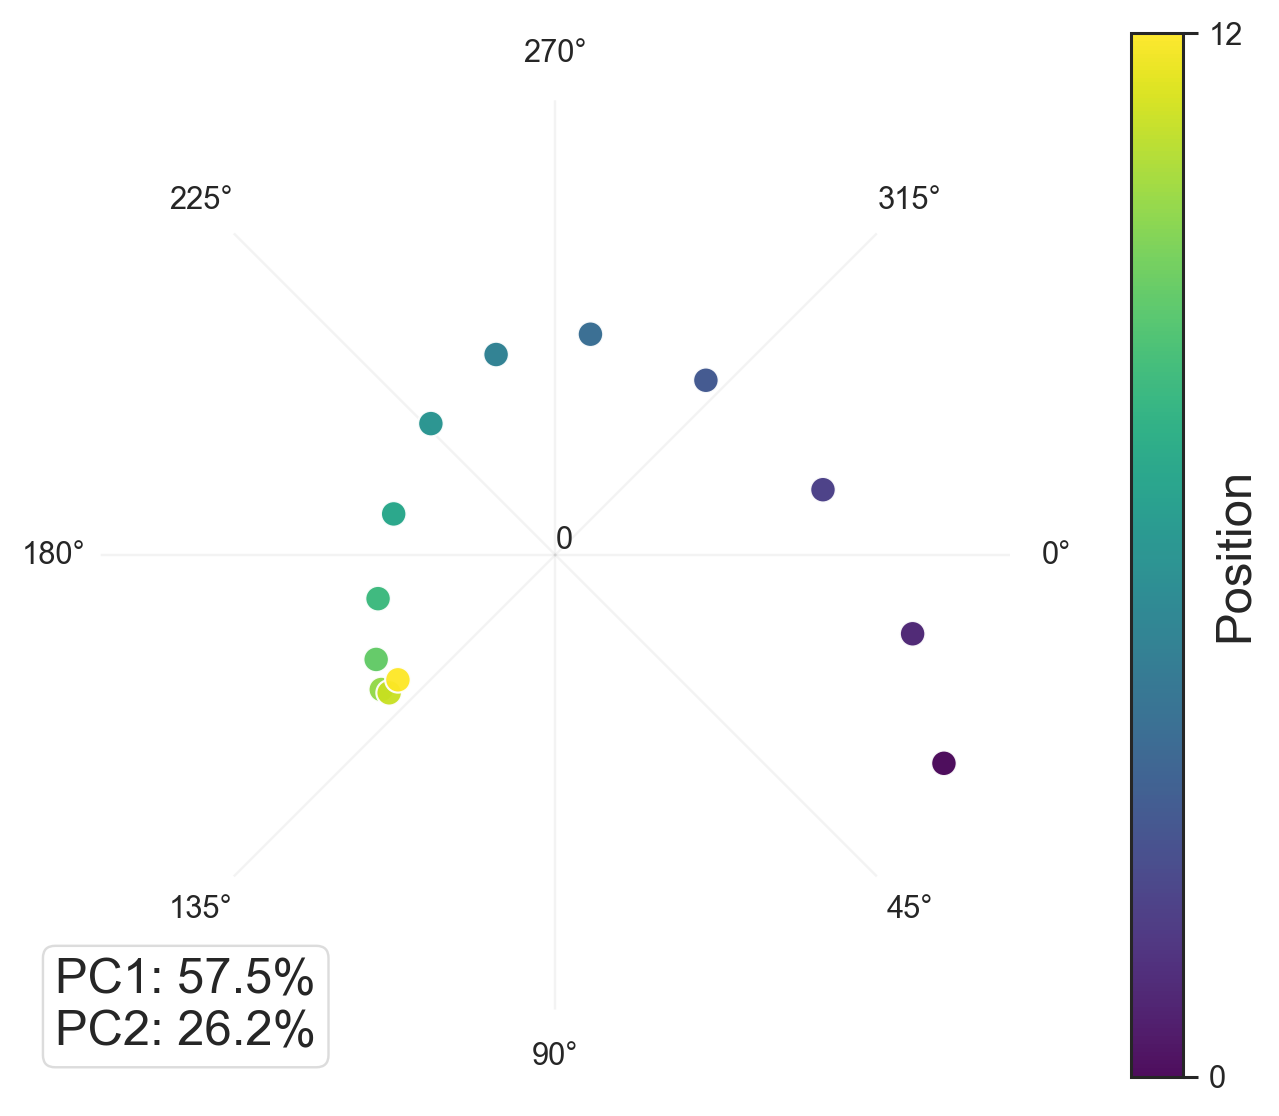

In [220]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="white", context="paper", font_scale=1.15)

pca = PCA(n_components=2)
scales_2d = pca.fit_transform(spiral_out[:13])

angles = np.arctan2(scales_2d[:, 1], scales_2d[:, 0])
r = np.linalg.norm(scales_2d, axis=1)
pos = np.arange(len(scales_2d))

fig, ax = plt.subplots(figsize=(6.2, 5.6), subplot_kw={"projection": "polar"}, dpi=220)

scatter = ax.scatter(
    angles,
    r,
    c=pos,
    cmap="viridis",
    s=70,
    alpha=0.95,
    edgecolors="white",
    linewidths=0.7,
)

# ax.set_title(
#     "      Position Modulation PCA in polar coordinates - Spiral",
#     pad=10,
#     fontsize=20,
# )

ax.set_theta_zero_location("E")
ax.set_theta_direction(-1)

ax.set_rticks([0])
ax.set_rlabel_position(135)
ax.grid(alpha=0.22, linewidth=0.8)

ax.spines["polar"].set_visible(False)

cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.90)
cbar.set_label("Position", rotation=90, labelpad=-10, fontsize=16)
cbar.set_ticks([0, len(scales_2d) - 1])

# Put the PCA variance in a compact note instead of x/y labels
var1, var2 = pca.explained_variance_ratio_[:2] * 100
ax.text(
    -0.05,
    -0.05,
    f"PC1: {var1:.1f}%\nPC2: {var2:.1f}%",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=16,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.85", alpha=0.9),
)

plt.tight_layout()
plt.show()

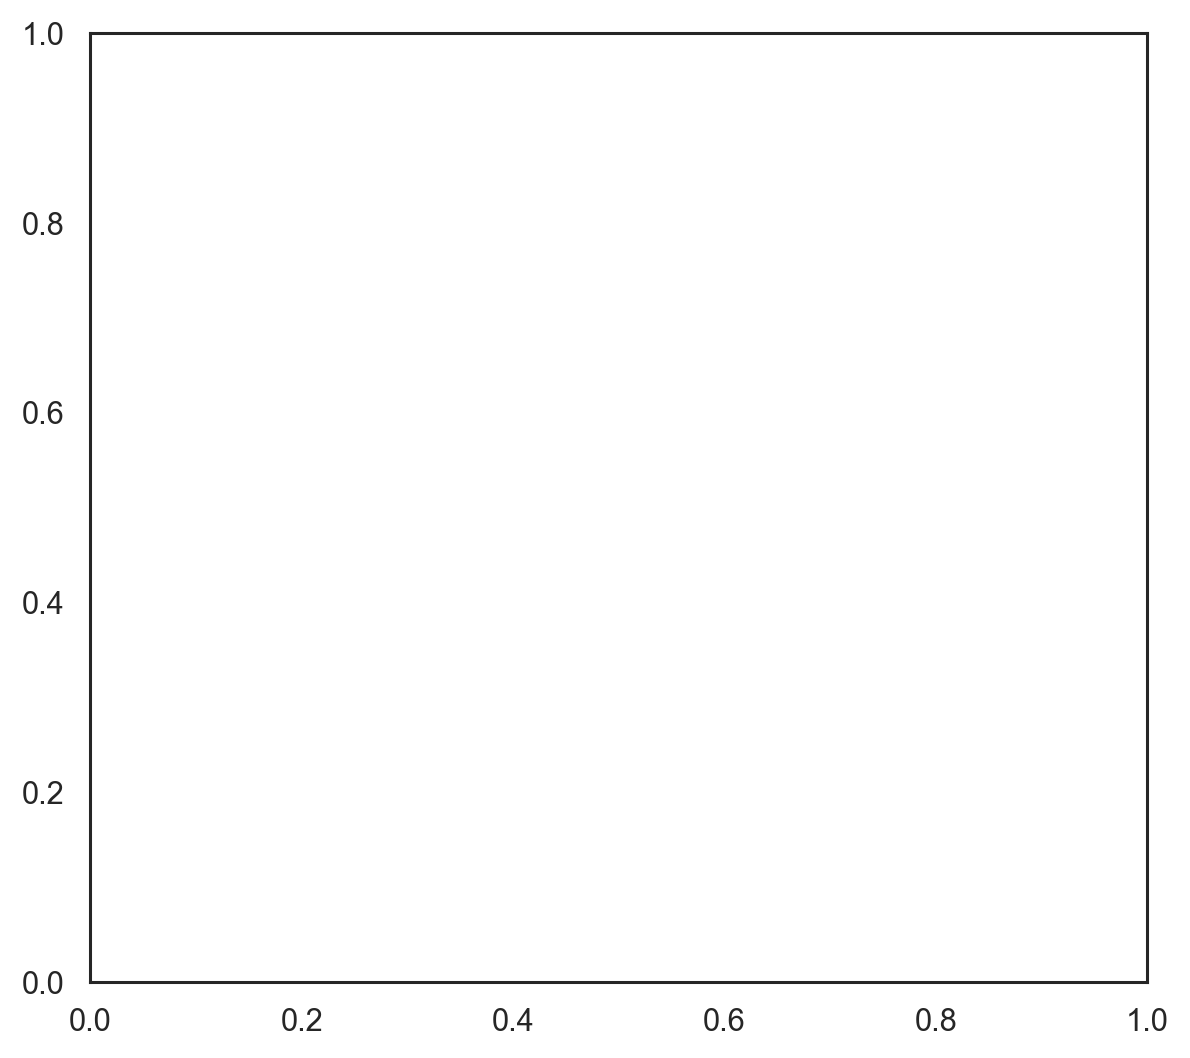

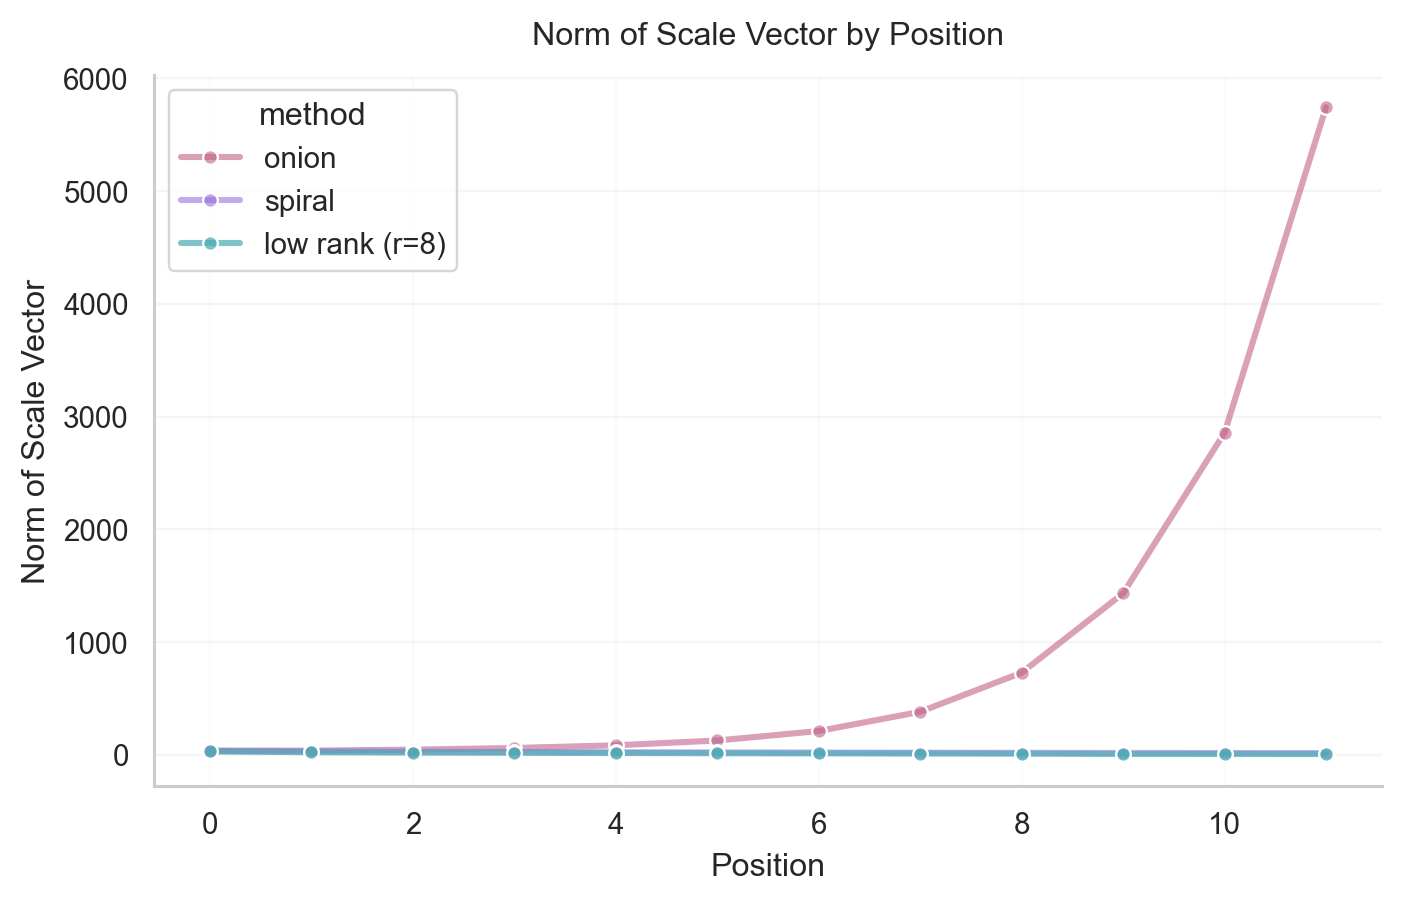

In [148]:
# norm of scales per position for spiral and low-rank, onion
max_pos =12
norm_df = pd.DataFrame({
    "position": np.arange(max_pos),
    "spiral": np.linalg.norm(spiral_params["scales"][:max_pos], axis=1),
    "onion": np.linalg.norm(onion_params["scales"][:max_pos], axis=1),
    "low rank (r=8)": np.linalg.norm(low_rank_params["scales"][:max_pos], axis=1),
})

sns.set_theme(style="white", context="paper", font_scale=1.15)
fig, ax = plt.subplots(figsize=(6.2, 5.6), dpi=220)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

palette = method_colors

fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=220)
sns.lineplot(
    data=norm_df.melt(id_vars="position", var_name="method", value_name="norm"),
    x="position",
    y="norm",
    hue="method",
    hue_order=["onion", "spiral", "low rank (r=8)"],
    palette=palette,
    estimator="mean",
    errorbar="sd",   # use ci="sd" if your seaborn is older
    err_style="band",
    err_kws={"alpha": 0.18},
    linewidth=2,
    marker="o",
    ax=ax,
)

ax.set_xlabel("Position")
ax.set_ylabel("Norm of Scale Vector")
ax.set_title("Norm of Scale Vector by Position", pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", alpha=0.08)   

In [2]:
import pandas as pd
import numpy as np
# from intervention.state_analysis.states_extract import StatesDataset
from sklearn.metrics.pairwise import cosine_similarity


phoneme_data = pd.read_csv(DATASETS_DIR / "phonemes.csv")
vowels = phoneme_data['Phoneme'][phoneme_data['Type'] == 'V'].tolist()
consonants = phoneme_data['Phoneme'][phoneme_data['Type'] == 'C'].tolist()

In [20]:


def compute_category_similarities(ds, category1, category2, embedding_col, max_samples=1000000):
    """Compute cosine similarities between two categories of phonemes (vectorized)."""
    mask1 = ds.metadata['phoneme'].isin(category1).values
    mask2 = ds.metadata['phoneme'].isin(category2).values

    arr = getattr(ds, embedding_col)
    data1 = arr[mask1]
    data2 = arr[mask2]

    # Subsample inputs BEFORE computing pairwise matrix to avoid OOM
    n = int(np.sqrt(max_samples)) + 1
    if len(data1) > n:
        data1 = data1[np.random.choice(len(data1), n, replace=False)]
    if len(data2) > n:
        data2 = data2[np.random.choice(len(data2), n, replace=False)]
    
    sim_matrix = cosine_similarity(data1, data2)

    same_category = set(category1) == set(category2)
    if same_category:
        sims = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
    else:
        sims = sim_matrix.flatten()

    if len(sims) > max_samples:
        sims = np.random.choice(sims, size=max_samples, replace=False)

    return sims

# states_ds = StatesDataset.load(str(STATES_DIR / "train_states"))
sims_C_C = compute_category_similarities(states_ds, consonants, consonants, 'delta_state')
sims_C_V = compute_category_similarities(states_ds, consonants, vowels, 'delta_state')
sims_V_V = compute_category_similarities(states_ds, vowels, vowels, 'delta_state')

C-V median: -0.0447
C-C median: 0.0996
V-V median: 0.1806


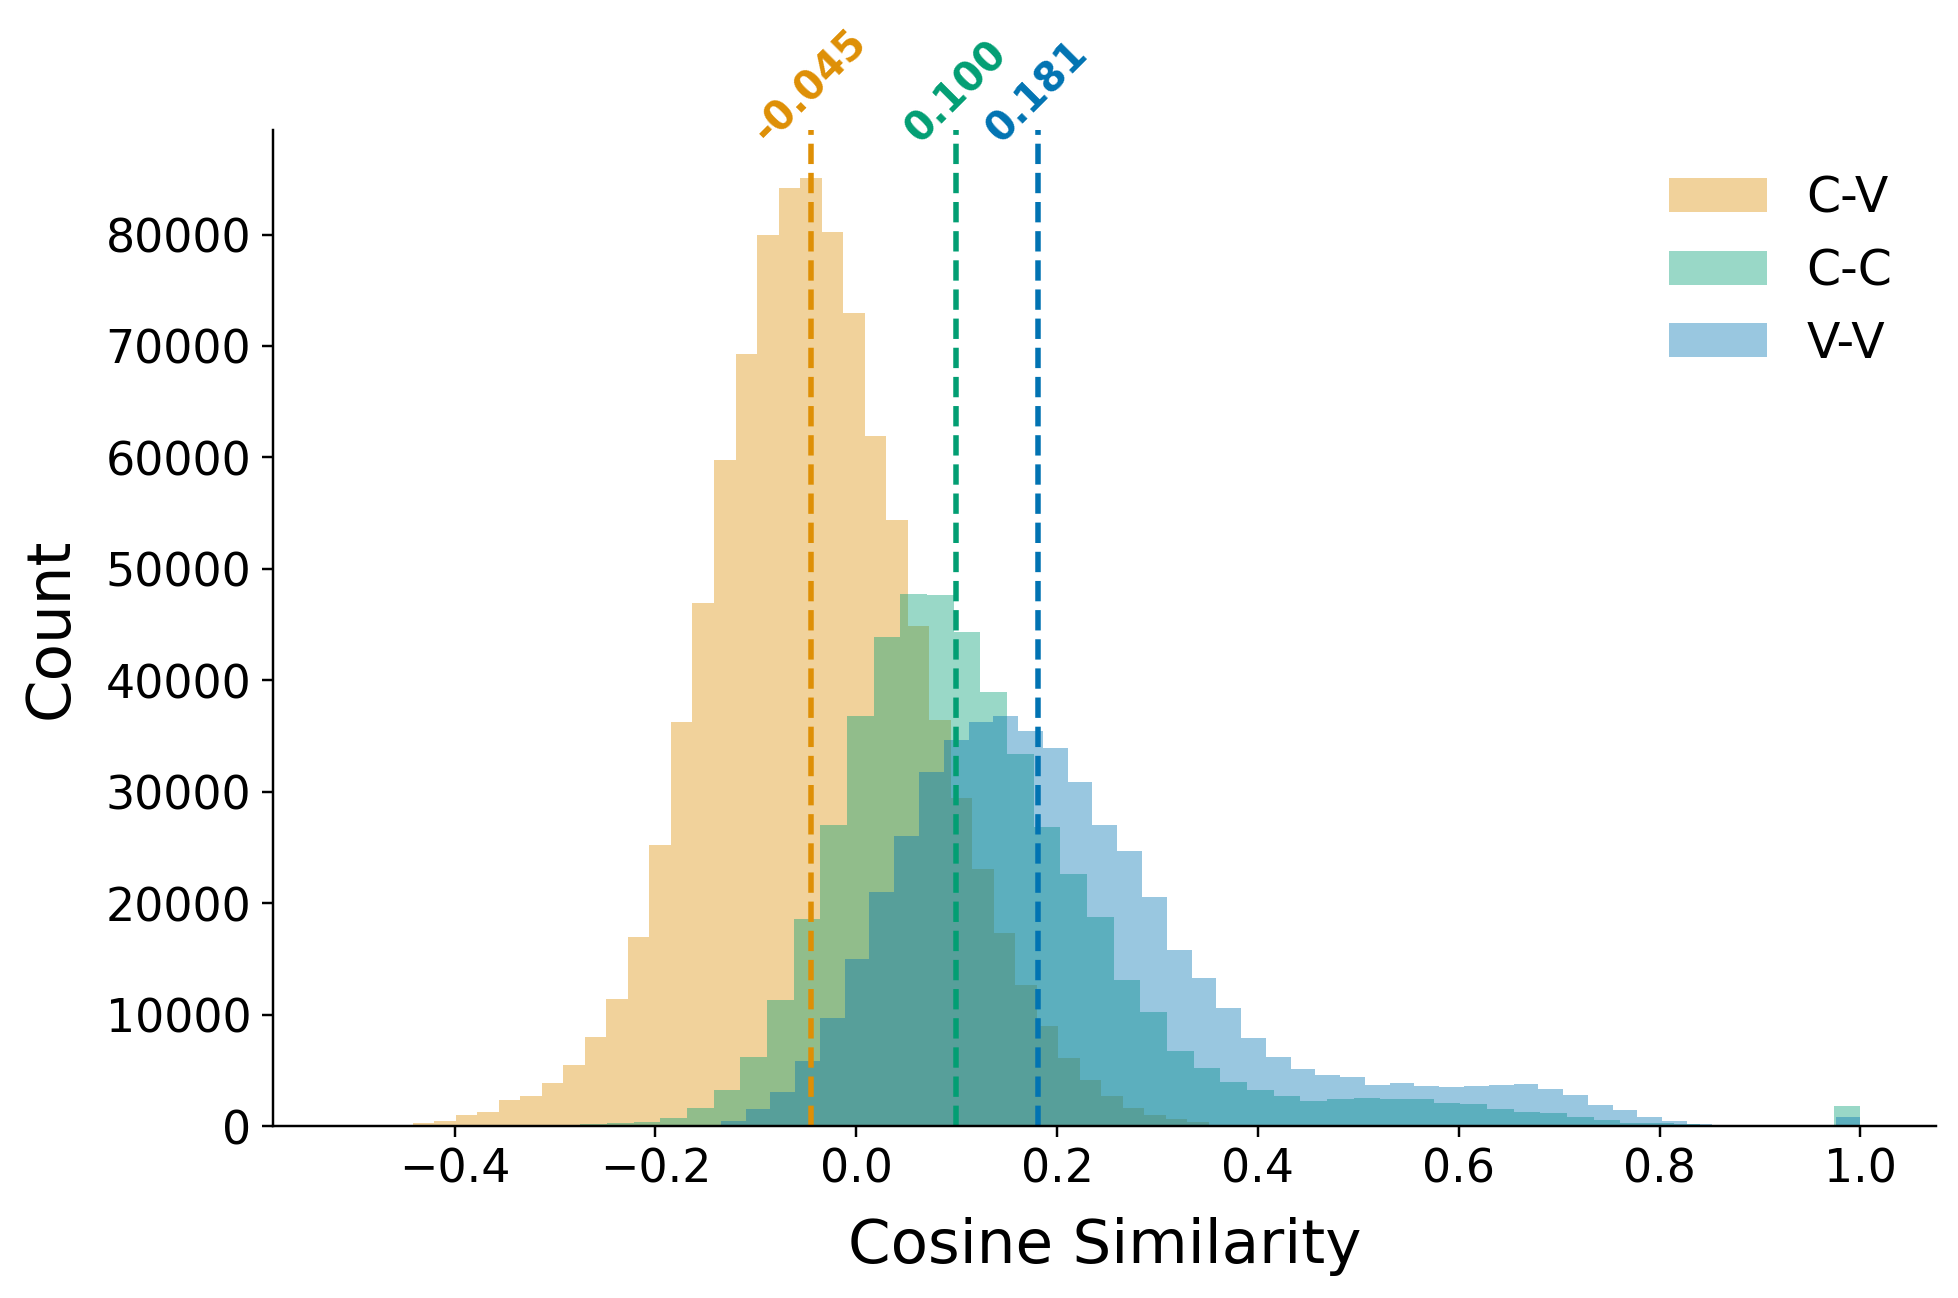

In [21]:

# fig, ax = plt.subplots(figsize=(10, 8))
# palette = sns.color_palette()  # default color cycle
# group_colors = {'V-V': palette[0], 'C-V': palette[1], 'C-C': palette[2]}

fig, ax = plt.subplots(figsize=(9, 6), dpi=220)

# colorblind-safe categorical hues, fixed order per group
cb = sns.color_palette("colorblind")
group_colors = {'V-V': cb[0], 'C-V': cb[1], 'C-C': cb[2]}

for sims, label in zip((sims_C_V, sims_C_C, sims_V_V), ['C-V', 'C-C', 'V-V']):
    median = np.median(sims)
    print(f"{label} median: {median:.4f}")
    color = group_colors[label]
    sns.histplot(sims, label=label, alpha=0.4, stat='count', bins=50, ax=ax,
                 color=color, edgecolor='none')
    ax.axvline(median, linestyle='--', linewidth=1.8, color=color)
    ax.text(median, ax.get_ylim()[1] * 0.98, f'{median:.3f}', color=color,
            ha='center', va='bottom', fontsize=13, fontweight='bold', rotation=45)

ax.set_xlabel('Cosine Similarity', fontsize=20, labelpad=8)
ax.set_ylabel('Count', fontsize=20, labelpad=8)
ax.tick_params(axis='both', labelsize=15)
ax.legend(fontsize=16, frameon=False)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("cosine_similarity_dz.pdf", bbox_inches="tight")
plt.show()



In [ ]:
# set the root to intervention (two levels up from plotting/)
import sys, pathlib
root = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(root))

In [30]:
suprisal_beta = pd.read_csv(root / "plots/surprisal/betas.csv")
suprisal_beta[suprisal_beta["target"]=="delta_state"]

,target,model,position,s_bigram,s_trigram,s_cohort,r2,shift_%
16,delta_state,position only,-0.4483,NaN,NaN,NaN,0.6791,0.0000
17,delta_state,s_bigram only,NaN,0.3308,NaN,NaN,0.1757,NaN
18,delta_state,s_trigram only,NaN,NaN,0.3201,NaN,0.1665,NaN
19,delta_state,s_cohort only,NaN,NaN,NaN,0.5537,0.4918,NaN
20,delta_state,position + s_bigram,-0.4183,0.1340,NaN,NaN,0.7049,6.6828
21,delta_state,position + s_trigram,-0.4203,NaN,0.1262,NaN,0.7024,6.2460
22,delta_state,position + s_cohort,-0.3481,NaN,NaN,0.2203,0.7231,22.3420
23,delta_state,position + all,-0.3472,0.0857,-0.0100,0.1850,0.7307,22.5358


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from intervention.models.repeat_model import get_model
from intervention.paths import get_phoneme_to_id, get_train_dataset, resolve_weights
from intervention.utils import seed_everything, set_device
from intervention.state_analysis.random_baseline import profiles
MODEL_NAME = "Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1"
WEIGHTS = "resources/weights/1024_75.pth"
TARGETS = ["delta_state"]
SEEDS = [0, 1, 2]
MAX_POS = 12 
PLOTS_DIR = Path(__file__).resolve().parents[1] / "plots" / "random_baseline"


PLOTS_DIR.mkdir(parents=True, exist_ok=True)
device = set_device()
phoneme_to_id = get_phoneme_to_id()
seqs = [list(p) + ["<EOS>"] for p in get_train_dataset()["No_Stress"]]
print(f"{len(seqs)} words, {sum(len(s) for s in seqs)} phoneme tokens")

prof = profiles(seqs, phoneme_to_id, device)
prof.to_csv(PLOTS_DIR / "profiles.csv", index=False)


# Headline number: how much of the decline is already there before any training?
kept = prof[(prof["position"] >= 1) & (prof["position"] <= MAX_POS)]
decay = kept.pivot_table(index=["target", "model"], columns="position", values="norm")
decay = (decay[MAX_POS] / decay[1]).rename(f"norm[{MAX_POS}] / norm[1]")
print("\n=== decay ratio ===")
print(decay.round(3).to_string())
print(f"\nplots + profiles.csv -> {PLOTS_DIR}")

Using MPS device
30000 words, 217229 phoneme tokens
  trained: done
  random s0: done
  random s1: done
  random s2: done

=== decay ratio ===
target       model    
delta_c      random s0    1.056
             random s1    1.014
             random s2    1.030
             trained      0.668
delta_h      random s0    1.053
             random s1    1.020
             random s2    1.025
             trained      0.711
delta_state  random s0    1.055
             random s1    1.015
             random s2    1.029
             trained      0.682


,target,position,norm,model
0,delta_c,0,7.088236,trained
1,delta_c,1,8.384104,trained
2,delta_c,2,8.203197,trained
3,delta_c,3,7.392150,trained
4,delta_c,4,6.556888,trained
...,...,...,...,...
211,delta_state,13,3.499146,random s2
212,delta_state,14,3.464504,random s2
213,delta_state,15,3.398729,random s2
214,delta_state,16,3.518685,random s2


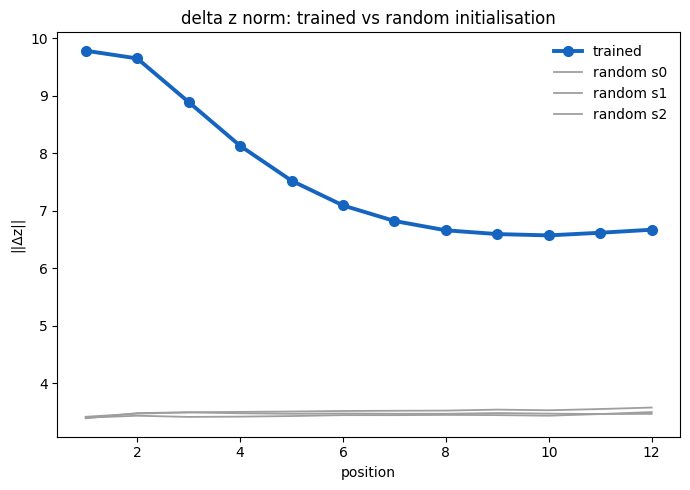

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from intervention.state_analysis.random_baseline import PLOTS_DIR, MAX_POS

RESCALE = False  # each curve relative to its own position 1; False for raw norms

prof = pd.read_csv(PLOTS_DIR / "profiles.csv")
d = prof[(prof["target"] == "delta_state") & prof["position"].between(1, MAX_POS)]

fig, ax = plt.subplots(figsize=(7, 5))
for label, grp in d.groupby("model", sort=False):
    y = grp.set_index("position")["norm"]
    if RESCALE:
        y = y / y.iloc[0]
    trained = label == "trained"
    ax.plot(y.index, y.values, label=label,
            color="#1565C0" if trained else "#9E9E9E",
            lw=2.8 if trained else 1.3,
            marker="o" if trained else None, markersize=7,
            zorder=3 if trained else 1)

if RESCALE:
    ax.axhline(1.0, color="k", lw=0.6, ls=":")
ax.set(xlabel="position",
       ylabel="||Δz|| relative to position 1" if RESCALE else "||Δz||",
       title="delta z norm: trained vs random initialisation")
ax.legend(frameon=False)
plt.tight_layout()
